# 2021~2025 MLB 타자 클러스터링 정리본

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
import re

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
# 선수 이름 정리 
# "Last, First" 형식 → "first last" 형식으로 변환
# 악센트/Jr./Sr./마침표/하이픈 등 제거

def clean_name(name):
    if pd.isna(name):
        return np.nan

    name = str(name).strip()

    if "," in name:
        parts = name.split(",")
        last = parts[0].strip()
        first = parts[1].strip()
        name = first + " " + last

    name = unicodedata.normalize("NFKD", name)
    name = "".join([c for c in name if not unicodedata.combining(c)])

    name = name.lower()

    name = name.replace(".", "")
    name = name.replace(",", "")
    name = name.replace("'", "")
    name = name.replace("-", " ")

    name = re.sub(r"\b(jr|sr|ii|iii|iv|v)\b", "", name)

    name = " ".join(name.split())

    parts = name.split()
    if len(parts) >= 3 and len(parts[0]) == 1 and len(parts[1]) == 1:
        parts = [parts[0] + parts[1]] + parts[2:]
        name = " ".join(parts)

    return name

In [3]:
# 2021~2025 Savant 타자 데이터 불러오기 + year 생성

batter_files = {
    2021: r"C:/Users/donge/OneDrive/바탕 화면/마린스 21-25 타자 데이터/21-5할 이상 팀 타자.csv",
    2022: r"C:/Users/donge/OneDrive/바탕 화면/마린스 21-25 타자 데이터/22-5할 이상 팀 타자.csv",
    2023: r"C:/Users/donge/OneDrive/바탕 화면/마린스 21-25 타자 데이터/23-5할 이상 팀 타자.csv",
    2024: r"C:/Users/donge/OneDrive/바탕 화면/마린스 21-25 타자 데이터/24-5할 이상 팀 타자.csv",
    2025: r"C:/Users/donge/OneDrive/바탕 화면/마린스 21-25 타자 데이터/25-5할 이상 팀 타자.csv"
}

batter_list = []

for year, path in batter_files.items():
    temp = pd.read_csv(path)

    temp.columns = (
        temp.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

    temp["year"] = year
    temp["player_name_clean"] = temp["player_name"].apply(clean_name)

    print(year, "행 수:", len(temp))

    batter_list.append(temp)

batter_5yr = pd.concat(batter_list, ignore_index=True)

print("5개년 전체 행 수:", len(batter_5yr))
batter_5yr[["year", "player_name", "player_name_clean"]].head()


2021 행 수: 531
2022 행 수: 373
2023 행 수: 349
2024 행 수: 392
2025 행 수: 383
5개년 전체 행 수: 2028


,year,player_name,player_name_clean
0,2021,"Crawford, J.P.",jp crawford
1,2021,"LeMahieu, DJ",dj lemahieu
2,2021,"Chapman, Matt",matt chapman
3,2021,"Devers, Rafael",rafael devers
4,2021,"Semien, Marcus",marcus semien


In [4]:
# Lahman Batting + People 불러오기
# Batting.csv: yearID, playerID, teamID
# People.csv: playerID, nameFirst, nameLast

batting_lahman = pd.read_csv(r"C:/Users/donge/OneDrive/바탕 화면/마린스 21-25 타자 데이터/Batting.csv")
people = pd.read_csv(r"C:/Users/donge/OneDrive/바탕 화면/마린스 21-25 타자 데이터/People.csv")

batting_lahman = batting_lahman[
    batting_lahman["yearID"].between(2021, 2025)
].copy()

batting_lahman["lahman_pa"] = (
    batting_lahman["AB"].fillna(0) +
    batting_lahman["BB"].fillna(0) +
    batting_lahman["HBP"].fillna(0) +
    batting_lahman["SF"].fillna(0) +
    batting_lahman["SH"].fillna(0)
)

people_id = people[["playerID", "nameFirst", "nameLast"]].copy()

people_id["player_name_lahman"] = (
    people_id["nameFirst"].astype(str) + " " + people_id["nameLast"].astype(str)
)

lahman_team = batting_lahman.merge(
    people_id,
    on="playerID",
    how="left"
)

lahman_team["player_name_clean"] = lahman_team["player_name_lahman"].apply(clean_name)

lahman_team[["yearID", "player_name_lahman", "player_name_clean", "teamID", "lahman_pa"]].head()

,yearID,player_name_lahman,player_name_clean,teamID,lahman_pa
0,2021,Fernando Abad,fernando abad,BAL,0.0
1,2023,Fernando Abad,fernando abad,COL,0.0
2,2023,Andrew Abbott,andrew abbott,CIN,0.0
3,2024,Andrew Abbott,andrew abbott,CIN,0.0
4,2025,Andrew Abbott,andrew abbott,CIN,0.0


In [5]:
# Lahman 팀 데이터 중복 제거
# 한 선수가 한 시즌에 여러 팀에서 뛰면 PA가 가장 많은 팀을 대표 팀으로 선택

lahman_team_unique = (
    lahman_team
    .sort_values(
        ["yearID", "player_name_clean", "lahman_pa"],
        ascending=[True, True, False]
    )
    .drop_duplicates(subset=["yearID", "player_name_clean"], keep="first")
    .copy()
)

print(
    "Lahman unique 중복 수:",
    lahman_team_unique.duplicated(subset=["yearID", "player_name_clean"]).sum()
)

lahman_team_unique[["yearID", "player_name_clean", "teamID", "lahman_pa"]].head()

Lahman unique 중복 수: 0


,yearID,player_name_clean,teamID,lahman_pa
380,2021,aaron ashby,MIL,4.0
1029,2021,aaron bummer,CHA,0.0
1447,2021,aaron civale,CLE,2.0
2362,2021,aaron fletcher,SEA,0.0
3341,2021,aaron hicks,NYA,126.0


In [6]:
# Savant 데이터에 team 붙이기
# validate="m:1"을 넣어서 행 수가 불어나는 merge를 방지함

batter_5yr = batter_5yr.loc[:, ~batter_5yr.columns.isin(["team", "yearID"])].copy()

before_rows = len(batter_5yr)

batter_5yr = batter_5yr.merge(
    lahman_team_unique[["yearID", "player_name_clean", "teamID"]],
    left_on=["year", "player_name_clean"],
    right_on=["yearID", "player_name_clean"],
    how="left",
    validate="m:1"
)

batter_5yr = batter_5yr.rename(columns={"teamID": "team"})
batter_5yr = batter_5yr.drop(columns=["yearID"])

after_rows = len(batter_5yr)

print("merge 전 행 수:", before_rows)
print("merge 후 행 수:", after_rows)
print("team 없는 행 수:", batter_5yr["team"].isna().sum())
print("team 붙은 행 수:", batter_5yr["team"].notna().sum())

merge 전 행 수: 2028
merge 후 행 수: 2028
team 없는 행 수: 6
team 붙은 행 수: 2022


In [7]:
# PA 150 이상 필터링

batter_5yr["pa"] = pd.to_numeric(batter_5yr["pa"], errors="coerce")

batter_5yr_pa150 = batter_5yr[batter_5yr["pa"] >= 150].copy()

print("PA 150 이상 행 수:", len(batter_5yr_pa150))
print("PA 150 이상 중 team 없는 행 수:", batter_5yr_pa150["team"].isna().sum())
print("PA 150 이상 중 team 붙은 행 수:", batter_5yr_pa150["team"].notna().sum())

batter_5yr_pa150["year"].value_counts().sort_index()

PA 150 이상 행 수: 816
PA 150 이상 중 team 없는 행 수: 3
PA 150 이상 중 team 붙은 행 수: 813


year
2021    143
2022    162
2023    168
2024    184
2025    159
Name: count, dtype: int64

In [8]:
# team 결측치 연도별 확인

team_missing_by_year = batter_5yr_pa150.groupby("year").agg(
    전체행수=("player_name", "count"),
    team없는행수=("team", lambda x: x.isna().sum()),
    team붙은행수=("team", lambda x: x.notna().sum())
)

team_missing_by_year["team없는비율(%)"] = (
    team_missing_by_year["team없는행수"] / team_missing_by_year["전체행수"] * 100
).round(2)

team_missing_by_year

,전체행수,team없는행수,team붙은행수,team없는비율(%)
year,,,,
2021,143,2,141,1.4
2022,162,0,162,0.0
2023,168,1,167,0.6
2024,184,0,184,0.0
2025,159,0,159,0.0


In [9]:
# team 안 붙은 선수 확인

unmatched_pa150 = batter_5yr_pa150[batter_5yr_pa150["team"].isna()][
    ["year", "player_name", "player_name_clean", "pa"]
].drop_duplicates()

unmatched_pa150

,year,player_name,player_name_clean,pa
131,2021,"Vogelbach, Daniel",daniel vogelbach,153.0
145,2021,"Frazier, Clint",clint frazier,154.0
1022,2023,"Taylor, Michael A.",michael a taylor,198.0


In [10]:
# 현재 확인된 3명을 수동 팀 매핑

manual_team_map = {
    (2021, "daniel vogelbach"): "MIL",
    (2021, "clint frazier"): "NYA",
    (2023, "michael a taylor"): "MIN"
}

for (year, name_clean), team in manual_team_map.items():
    condition = (
        (batter_5yr_pa150["year"] == year) &
        (batter_5yr_pa150["player_name_clean"] == name_clean) &
        (batter_5yr_pa150["team"].isna())
    )

    batter_5yr_pa150.loc[condition, "team"] = team

print("PA 150 이상 중 team 없는 행 수:", batter_5yr_pa150["team"].isna().sum())
print("PA 150 이상 중 team 붙은 행 수:", batter_5yr_pa150["team"].notna().sum())

PA 150 이상 중 team 없는 행 수: 0
PA 150 이상 중 team 붙은 행 수: 816


In [11]:
# 최종 클러스터링 기준 데이터 만들기
# 클러스터링 fit 기준은 '승률 5할 이상 팀'만 사용
# Miami(MIA)는 비교 대상이므로 기준 데이터에서 제외

# Lahman teamID 기준 2021~2025 승률 5할 이상 팀 목록
# 2023년 Miami는 승률 5할 이상이지만, 여기서는 비교 대상이므로 아래 필터에서 제외함.
win500_teams_by_year = {
    2021: ["TBA", "BOS", "NYA", "TOR", "CHA", "HOU", "SEA", "OAK", "ATL", "PHI", "MIL", "SLN", "CIN", "SFN", "LAN"],
    2022: ["NYA", "TOR", "TBA", "BAL", "CLE", "CHA", "HOU", "SEA", "ATL", "NYN", "PHI", "SLN", "MIL", "LAN", "SDN", "SFN"],
    2023: ["BAL", "TBA", "TOR", "NYA", "MIN", "HOU", "TEX", "SEA", "ATL", "PHI", "MIA", "MIL", "CHN", "CIN", "LAN", "ARI", "SDN"],
    2024: ["NYA", "BAL", "BOS", "CLE", "KCA", "DET", "MIN", "HOU", "SEA", "PHI", "ATL", "NYN", "MIL", "SLN", "CHN", "LAN", "SDN", "ARI"],
    2025: ["TOR", "NYA", "BOS", "CLE", "DET", "KCA", "SEA", "HOU", "TEX", "PHI", "NYN", "MIL", "CHN", "CIN", "LAN", "SDN", "SFN"]
}

batter_all = batter_5yr_pa150.copy()

# team 코드 정리
batter_all["team"] = batter_all["team"].apply(
    lambda x: np.nan if pd.isna(x) else str(x).strip().upper()
)

# 기준 후보 데이터 안에 Miami가 섞여 있는지 확인
mia_in_source = batter_all[batter_all["team"] == "MIA"].copy()
print("기준 후보 데이터 전체 행 수:", len(batter_all))
print("기준 후보 데이터 안의 MIA 행 수:", len(mia_in_source))

if len(mia_in_source) > 0:
    print("\n기준 후보 데이터 안에 섞여 있던 MIA 행:")
    display(mia_in_source[["year", "team", "player_name", "pa"]].sort_values(["year", "player_name"]))

# 승률 5할 이상 팀 여부
batter_all["is_win500_team"] = batter_all.apply(
    lambda row: row["team"] in win500_teams_by_year.get(row["year"], []),
    axis=1
)

# 클러스터링 기준 데이터: 승률 5할 이상 팀이면서 Miami 제외
batter = batter_all[
    (batter_all["is_win500_team"]) &
    (batter_all["team"] != "MIA")
].copy()

batter["team_group"] = "5할 이상 팀"

print("\n최종 클러스터링 기준 행 수:", len(batter))
print("최종 클러스터링 기준 데이터 안의 MIA 행 수:", (batter["team"] == "MIA").sum())
print("team 결측치:", batter["team"].isna().sum())
print("\n연도별 행 수")
print(batter["year"].value_counts().sort_index())


기준 후보 데이터 전체 행 수: 816
기준 후보 데이터 안의 MIA 행 수: 1

기준 후보 데이터 안에 섞여 있던 MIA 행:


,year,team,player_name,pa
152,2021,MIA,"Marte, Starling",158.0



최종 클러스터링 기준 행 수: 815
최종 클러스터링 기준 데이터 안의 MIA 행 수: 0
team 결측치: 0

연도별 행 수
year
2021    142
2022    162
2023    168
2024    184
2025    159
Name: count, dtype: int64


In [12]:
# 클러스터링 변수 선택
# 5개년 통합에서는 bat_speed, swing_length 결측이 많아서 이거 두 개는 제외함

feature_cols_v2 = [
    "xba",
    "bb_percent",
    "iso",
    "k_percent",
    "swing_miss_percent",
    "launch_speed",
    "launch_angle",
    "hardhit_percent",
    "barrels_per_bbe_percent",
    "batter_run_value_per_100"
]

feature_cols_v2 = [col for col in feature_cols_v2 if col in batter.columns]

feature_cols_v2

['xba',
 'bb_percent',
 'iso',
 'k_percent',
 'swing_miss_percent',
 'launch_speed',
 'launch_angle',
 'hardhit_percent',
 'barrels_per_bbe_percent',
 'batter_run_value_per_100']

In [13]:
# X 만들고 숫자형 변환, 결측치 확인

X_v2 = batter[feature_cols_v2].copy()

for col in feature_cols_v2:
    X_v2[col] = pd.to_numeric(X_v2[col], errors="coerce")

missing_v2 = X_v2.isna().sum().sort_values(ascending=False)

print(missing_v2)
print("결측치 총 개수:", X_v2.isna().sum().sum())

xba                         0
bb_percent                  0
iso                         0
k_percent                   0
swing_miss_percent          0
launch_speed                0
launch_angle                0
hardhit_percent             0
barrels_per_bbe_percent     0
batter_run_value_per_100    0
dtype: int64
결측치 총 개수: 0


In [14]:
# 표준화

scaler_v2 = StandardScaler()

X_v2_scaled = scaler_v2.fit_transform(X_v2)

batter_cluster_scaled_v2 = pd.DataFrame(
    X_v2_scaled,
    columns=feature_cols_v2,
    index=batter.index
)

batter_cluster_scaled_v2.describe().round(3)

,xba,bb_percent,iso,k_percent,swing_miss_percent,launch_speed,launch_angle,hardhit_percent,barrels_per_bbe_percent,batter_run_value_per_100
count,815.000,815.000,815.000,815.000,815.000,815.000,815.000,815.000,815.000,815.000
mean,-0.000,-0.000,0.000,-0.000,0.000,-0.000,0.000,-0.000,0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-3.714,-2.241,-2.396,-2.941,-2.659,-3.793,-2.922,-3.388,-1.945,-3.114
25%,-0.660,-0.740,-0.757,-0.723,-0.701,-0.668,-0.676,-0.671,-0.763,-0.676
50%,0.007,-0.063,-0.102,-0.078,-0.003,0.034,-0.018,0.038,-0.103,-0.054
75%,0.638,0.614,0.643,0.638,0.644,0.736,0.676,0.686,0.647,0.629
max,3.412,4.940,4.099,3.792,3.351,3.369,3.580,3.239,4.110,4.436


In [15]:
# k별 inertia / silhouette score 계산

inertia_list_v2 = []
silhouette_list_v2 = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(batter_cluster_scaled_v2)

    inertia_list_v2.append(kmeans.inertia_)
    silhouette_list_v2.append(silhouette_score(batter_cluster_scaled_v2, labels))

k_result_v2 = pd.DataFrame({
    "k": list(K_range),
    "inertia": inertia_list_v2,
    "silhouette_score": silhouette_list_v2
})

k_result_v2.sort_values("silhouette_score", ascending=False)

,k,inertia,silhouette_score
0,2,5838.904356,0.240673
1,3,5000.580883,0.210015
2,4,4507.285345,0.168769
4,6,3844.170742,0.166348
3,5,4156.532545,0.160417
6,8,3503.585585,0.148942
5,7,3656.529133,0.147597
7,9,3392.504656,0.136455
8,10,3260.821426,0.131735


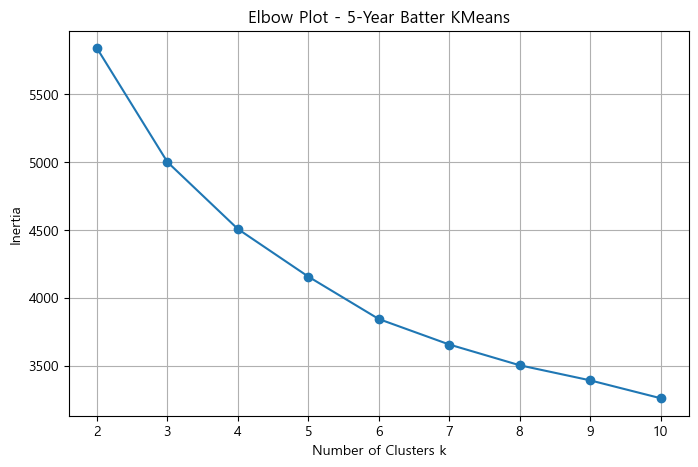

In [16]:
# Elbow plot

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_list_v2, marker="o")
plt.xlabel("Number of Clusters k")
plt.ylabel("Inertia")
plt.title("Elbow Plot - 5-Year Batter KMeans")
plt.grid(True)
plt.show()

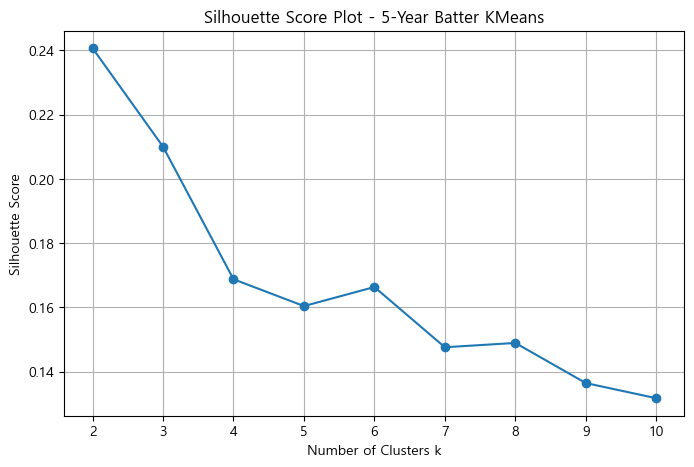

In [17]:
# Silhouette plot

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_list_v2, marker="o")
plt.xlabel("Number of Clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Plot - 5-Year Batter KMeans")
plt.grid(True)
plt.show()

In [18]:
# k=4 클러스터링

kmeans4_v2 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

batter["cluster_k4_v2"] = kmeans4_v2.fit_predict(batter_cluster_scaled_v2)

batter["cluster_k4_v2"].value_counts().sort_index()

cluster_k4_v2
0    192
1    240
2    130
3    253
Name: count, dtype: int64

In [19]:
# 클러스터별 변수 평균과 TOP 변수 확인

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)


# 원자료 기준 평균
cluster_k4_v2_summary = (
    batter
    .groupby("cluster_k4_v2")[feature_cols_v2]
    .mean()
    .round(3)
)

# 표준화 기준 평균
# 양수 = 전체 5할 이상 팀 평균보다 높음
# 음수 = 전체 5할 이상 팀 평균보다 낮음
cluster_profile_scaled_v2 = batter_cluster_scaled_v2.copy()
cluster_profile_scaled_v2["cluster_k4_v2"] = batter["cluster_k4_v2"].values

cluster_scaled_summary_v2 = (
    cluster_profile_scaled_v2
    .groupby("cluster_k4_v2")
    .mean()
    .round(2)
)

# 클러스터별 높은 변수 / 낮은 변수 정리
top_feature_rows = []

for c in sorted(cluster_scaled_summary_v2.index):
    sorted_features = cluster_scaled_summary_v2.loc[c].sort_values(ascending=False)

    top_feature_rows.append({
        "cluster": c,
        "선수 수": int((batter["cluster_k4_v2"] == c).sum()),
        "높은 변수 TOP5": ", ".join(sorted_features.head(5).index),
        "낮은 변수 TOP5": ", ".join(sorted_features.tail(5).index),
        "높은 변수값 TOP5": ", ".join([f"{idx}:{val:.2f}" for idx, val in sorted_features.head(5).items()]),
        "낮은 변수값 TOP5": ", ".join([f"{idx}:{val:.2f}" for idx, val in sorted_features.tail(5).items()])
    })

cluster_top_features_v2 = pd.DataFrame(top_feature_rows)

print("[클러스터별 원자료 평균]")
display(cluster_k4_v2_summary.T)

print()
print("[클러스터별 표준화 평균]")
display(cluster_scaled_summary_v2.T)

print()
print("[클러스터별 높은 변수 / 낮은 변수 TOP]")
display(cluster_top_features_v2)


[클러스터별 원자료 평균]


cluster_k4_v2,0,1,2,3
xba,0.238,0.256,0.294,0.278
bb_percent,11.152,9.370,12.146,9.953
iso,0.207,0.127,0.278,0.178
k_percent,24.674,14.383,18.185,16.403
swing_miss_percent,25.520,15.382,20.241,18.186
launch_speed,90.746,87.407,93.640,91.002
launch_angle,17.843,12.850,16.035,11.773
hardhit_percent,46.949,35.892,55.271,47.288
barrels_per_bbe_percent,12.481,4.685,16.269,8.904
batter_run_value_per_100,0.117,-0.421,1.637,0.437



[클러스터별 표준화 평균]


cluster_k4_v2,0,1,2,3
xba,-0.95,-0.30,1.01,0.48
bb_percent,0.22,-0.31,0.51,-0.14
iso,0.32,-0.88,1.38,-0.12
k_percent,1.17,-0.65,0.03,-0.29
swing_miss_percent,1.04,-0.69,0.14,-0.21
launch_speed,0.16,-1.02,1.17,0.25
launch_angle,0.67,-0.25,0.34,-0.44
hardhit_percent,0.21,-1.06,1.17,0.25
barrels_per_bbe_percent,0.56,-1.00,1.32,-0.16
batter_run_value_per_100,-0.19,-0.75,1.38,0.14



[클러스터별 높은 변수 / 낮은 변수 TOP]


,cluster,선수 수,높은 변수 TOP5,낮은 변수 TOP5,높은 변수값 TOP5,낮은 변수값 TOP5
0,0,192,"k_percent, swing_miss_percent, launch_angle, barrels_per_bbe_percent, iso","bb_percent, hardhit_percent, launch_speed, batter_run_value_per_100, xba","k_percent:1.17, swing_miss_percent:1.04, launch_angle:0.67, barrels_per_bbe_percent:0.56, iso:0.32","bb_percent:0.22, hardhit_percent:0.21, launch_speed:0.16, batter_run_value_per_100:-0.19, xba:-0.95"
1,1,240,"launch_angle, xba, bb_percent, k_percent, swing_miss_percent","batter_run_value_per_100, iso, barrels_per_bbe_percent, launch_speed, hardhit_percent","launch_angle:-0.25, xba:-0.30, bb_percent:-0.31, k_percent:-0.65, swing_miss_percent:-0.69","batter_run_value_per_100:-0.75, iso:-0.88, barrels_per_bbe_percent:-1.00, launch_speed:-1.02, hardhit_percent:-1.06"
2,2,130,"batter_run_value_per_100, iso, barrels_per_bbe_percent, launch_speed, hardhit_percent","xba, bb_percent, launch_angle, swing_miss_percent, k_percent","batter_run_value_per_100:1.38, iso:1.38, barrels_per_bbe_percent:1.32, launch_speed:1.17, hardhit_percent:1.17","xba:1.01, bb_percent:0.51, launch_angle:0.34, swing_miss_percent:0.14, k_percent:0.03"
3,3,253,"xba, launch_speed, hardhit_percent, batter_run_value_per_100, iso","bb_percent, barrels_per_bbe_percent, swing_miss_percent, k_percent, launch_angle","xba:0.48, launch_speed:0.25, hardhit_percent:0.25, batter_run_value_per_100:0.14, iso:-0.12","bb_percent:-0.14, barrels_per_bbe_percent:-0.16, swing_miss_percent:-0.21, k_percent:-0.29, launch_angle:-0.44"


In [20]:
# 클러스터 이름 붙이기
# 클러스터별 원자료 평균, 표준화 평균, 높은/낮은 변수 TOP 결과를 보고 붙임.

cluster_name_map_v2 = {
    0: "고삼진 장타 잠재형",
    1: "저삼진 약타구 저생산형",
    2: "엘리트 파워 생산형",
    3: "컨택 기반 평균형"
}

# 해석상 핵심 유형이 먼저 보이도록 정렬함.
cluster_order_v2 = [
    "엘리트 파워 생산형",
    "고삼진 장타 잠재형",
    "컨택 기반 평균형",
    "저삼진 약타구 저생산형"
]

cluster_interpretation_v2 = pd.DataFrame([
    {
        "cluster": 0,
        "cluster_name_v2": "고삼진 장타 잠재형",
        "핵심 특징": "k_percent, swing_miss_percent, launch_angle, barrels_per_bbe_percent가 높음",
        "해석": "삼진과 헛스윙은 많지만 장타성 타구를 만들 잠재력이 있는 유형. 다만 xba와 batter_run_value_per_100이 낮아 실제 생산성은 엘리트형보다 낮음."
    },
    {
        "cluster": 1,
        "cluster_name_v2": "저삼진 약타구 저생산형",
        "핵심 특징": "k_percent와 swing_miss_percent는 낮지만 iso, launch_speed, hardhit_percent, barrels_per_bbe_percent, batter_run_value_per_100이 낮음",
        "해석": "공을 맞히는 능력은 있지만 강한 타구와 장타 생산력이 부족한 유형. 공격 생산성이 가장 약한 기준집단으로 해석 가능함."
    },
    {
        "cluster": 2,
        "cluster_name_v2": "엘리트 파워 생산형",
        "핵심 특징": "xba, iso, launch_speed, hardhit_percent, barrels_per_bbe_percent, batter_run_value_per_100이 모두 높음",
        "해석": "장타력, 타구 질, 기대 타율, 득점 생산성이 모두 우수한 핵심 공격 자원 유형."
    },
    {
        "cluster": 3,
        "cluster_name_v2": "컨택 기반 평균형",
        "핵심 특징": "xba는 높고 k_percent, swing_miss_percent는 낮은 편이지만 iso, barrels_per_bbe_percent, launch_angle은 높지 않음",
        "해석": "삼진을 줄이고 컨택을 만드는 유형. 장타형보다는 컨택 중심이며 생산성은 평균권으로 해석 가능함."
    }
])

# 클러스터 이름 부여
batter["cluster_name_v2"] = batter["cluster_k4_v2"].map(cluster_name_map_v2)
batter["team_group"] = "5할 이상 팀"

# 비교용 기준팀 데이터 저장
batter_ref_clustered = batter.copy()

cluster_naming_table_v2 = cluster_top_features_v2.merge(
    cluster_interpretation_v2,
    on="cluster",
    how="left"
)

print("클러스터 이름 매핑")
print(cluster_name_map_v2)

print()
print("클러스터별 최종 이름 및 해석")
display(cluster_naming_table_v2)

batter[["year", "team", "player_name", "pa", "cluster_k4_v2", "cluster_name_v2"]].head()


클러스터 이름 매핑
{0: '고삼진 장타 잠재형', 1: '저삼진 약타구 저생산형', 2: '엘리트 파워 생산형', 3: '컨택 기반 평균형'}

클러스터별 최종 이름 및 해석


,cluster,선수 수,높은 변수 TOP5,낮은 변수 TOP5,높은 변수값 TOP5,낮은 변수값 TOP5,cluster_name_v2,핵심 특징,해석
0,0,192,"k_percent, swing_miss_percent, launch_angle, barrels_per_bbe_percent, iso","bb_percent, hardhit_percent, launch_speed, batter_run_value_per_100, xba","k_percent:1.17, swing_miss_percent:1.04, launch_angle:0.67, barrels_per_bbe_percent:0.56, iso:0.32","bb_percent:0.22, hardhit_percent:0.21, launch_speed:0.16, batter_run_value_per_100:-0.19, xba:-0.95",고삼진 장타 잠재형,"k_percent, swing_miss_percent, launch_angle, barrels_per_bbe_percent가 높음",삼진과 헛스윙은 많지만 장타성 타구를 만들 잠재력이 있는 유형. 다만 xba와 batter_run_value_per_100이 낮아 실제 생산성은 엘리트형보다 낮음.
1,1,240,"launch_angle, xba, bb_percent, k_percent, swing_miss_percent","batter_run_value_per_100, iso, barrels_per_bbe_percent, launch_speed, hardhit_percent","launch_angle:-0.25, xba:-0.30, bb_percent:-0.31, k_percent:-0.65, swing_miss_percent:-0.69","batter_run_value_per_100:-0.75, iso:-0.88, barrels_per_bbe_percent:-1.00, launch_speed:-1.02, hardhit_percent:-1.06",저삼진 약타구 저생산형,"k_percent와 swing_miss_percent는 낮지만 iso, launch_speed, hardhit_percent, barrels_per_bbe_percent, batter_run_value_per_100이 낮음",공을 맞히는 능력은 있지만 강한 타구와 장타 생산력이 부족한 유형. 공격 생산성이 가장 약한 기준집단으로 해석 가능함.
2,2,130,"batter_run_value_per_100, iso, barrels_per_bbe_percent, launch_speed, hardhit_percent","xba, bb_percent, launch_angle, swing_miss_percent, k_percent","batter_run_value_per_100:1.38, iso:1.38, barrels_per_bbe_percent:1.32, launch_speed:1.17, hardhit_percent:1.17","xba:1.01, bb_percent:0.51, launch_angle:0.34, swing_miss_percent:0.14, k_percent:0.03",엘리트 파워 생산형,"xba, iso, launch_speed, hardhit_percent, barrels_per_bbe_percent, batter_run_value_per_100이 모두 높음","장타력, 타구 질, 기대 타율, 득점 생산성이 모두 우수한 핵심 공격 자원 유형."
3,3,253,"xba, launch_speed, hardhit_percent, batter_run_value_per_100, iso","bb_percent, barrels_per_bbe_percent, swing_miss_percent, k_percent, launch_angle","xba:0.48, launch_speed:0.25, hardhit_percent:0.25, batter_run_value_per_100:0.14, iso:-0.12","bb_percent:-0.14, barrels_per_bbe_percent:-0.16, swing_miss_percent:-0.21, k_percent:-0.29, launch_angle:-0.44",컨택 기반 평균형,"xba는 높고 k_percent, swing_miss_percent는 낮은 편이지만 iso, barrels_per_bbe_percent, launch_angle은 높지 않음",삼진을 줄이고 컨택을 만드는 유형. 장타형보다는 컨택 중심이며 생산성은 평균권으로 해석 가능함.


,year,team,player_name,pa,cluster_k4_v2,cluster_name_v2
0,2021,SEA,"Crawford, J.P.",422.0,1,저삼진 약타구 저생산형
1,2021,NYA,"LeMahieu, DJ",377.0,3,컨택 기반 평균형
2,2021,OAK,"Chapman, Matt",385.0,0,고삼진 장타 잠재형
3,2021,BOS,"Devers, Rafael",395.0,0,고삼진 장타 잠재형
4,2021,TOR,"Semien, Marcus",454.0,2,엘리트 파워 생산형


In [21]:
# 클러스터별 선수 수 / 비율

cluster_count = (
    batter["cluster_name_v2"]
    .value_counts()
    .reindex(cluster_order_v2)
    .fillna(0)
    .astype(int)
)

cluster_ratio = (cluster_count / cluster_count.sum() * 100).round(2)

cluster_dist_v2 = pd.DataFrame({
    "선수 수": cluster_count,
    "비율(%)": cluster_ratio
})

cluster_dist_v2


,선수 수,비율(%)
cluster_name_v2,,
엘리트 파워 생산형,130,15.95
고삼진 장타 잠재형,192,23.56
컨택 기반 평균형,253,31.04
저삼진 약타구 저생산형,240,29.45


In [22]:
# 클러스터별 높은 변수 / 낮은 변수 + 대표 선수 확인

print("[클러스터별 높은 변수 / 낮은 변수 TOP + 최종 이름]")
display(cluster_naming_table_v2)

for c in sorted(batter["cluster_k4_v2"].unique()):
    print()
    print(f"===== Cluster {c}: {cluster_name_map_v2[c]} =====")

    display(
        batter[batter["cluster_k4_v2"] == c]
        .sort_values("batter_run_value_per_100", ascending=False)
        [[
            "year", "team", "player_name", "pa",
            "cluster_k4_v2", "cluster_name_v2",
            "xba", "bb_percent", "iso",
            "k_percent", "swing_miss_percent",
            "launch_speed", "hardhit_percent",
            "barrels_per_bbe_percent",
            "batter_run_value_per_100"
        ]]
        .head(10)
    )


[클러스터별 높은 변수 / 낮은 변수 TOP + 최종 이름]


,cluster,선수 수,높은 변수 TOP5,낮은 변수 TOP5,높은 변수값 TOP5,낮은 변수값 TOP5,cluster_name_v2,핵심 특징,해석
0,0,192,"k_percent, swing_miss_percent, launch_angle, barrels_per_bbe_percent, iso","bb_percent, hardhit_percent, launch_speed, batter_run_value_per_100, xba","k_percent:1.17, swing_miss_percent:1.04, launch_angle:0.67, barrels_per_bbe_percent:0.56, iso:0.32","bb_percent:0.22, hardhit_percent:0.21, launch_speed:0.16, batter_run_value_per_100:-0.19, xba:-0.95",고삼진 장타 잠재형,"k_percent, swing_miss_percent, launch_angle, barrels_per_bbe_percent가 높음",삼진과 헛스윙은 많지만 장타성 타구를 만들 잠재력이 있는 유형. 다만 xba와 batter_run_value_per_100이 낮아 실제 생산성은 엘리트형보다 낮음.
1,1,240,"launch_angle, xba, bb_percent, k_percent, swing_miss_percent","batter_run_value_per_100, iso, barrels_per_bbe_percent, launch_speed, hardhit_percent","launch_angle:-0.25, xba:-0.30, bb_percent:-0.31, k_percent:-0.65, swing_miss_percent:-0.69","batter_run_value_per_100:-0.75, iso:-0.88, barrels_per_bbe_percent:-1.00, launch_speed:-1.02, hardhit_percent:-1.06",저삼진 약타구 저생산형,"k_percent와 swing_miss_percent는 낮지만 iso, launch_speed, hardhit_percent, barrels_per_bbe_percent, batter_run_value_per_100이 낮음",공을 맞히는 능력은 있지만 강한 타구와 장타 생산력이 부족한 유형. 공격 생산성이 가장 약한 기준집단으로 해석 가능함.
2,2,130,"batter_run_value_per_100, iso, barrels_per_bbe_percent, launch_speed, hardhit_percent","xba, bb_percent, launch_angle, swing_miss_percent, k_percent","batter_run_value_per_100:1.38, iso:1.38, barrels_per_bbe_percent:1.32, launch_speed:1.17, hardhit_percent:1.17","xba:1.01, bb_percent:0.51, launch_angle:0.34, swing_miss_percent:0.14, k_percent:0.03",엘리트 파워 생산형,"xba, iso, launch_speed, hardhit_percent, barrels_per_bbe_percent, batter_run_value_per_100이 모두 높음","장타력, 타구 질, 기대 타율, 득점 생산성이 모두 우수한 핵심 공격 자원 유형."
3,3,253,"xba, launch_speed, hardhit_percent, batter_run_value_per_100, iso","bb_percent, barrels_per_bbe_percent, swing_miss_percent, k_percent, launch_angle","xba:0.48, launch_speed:0.25, hardhit_percent:0.25, batter_run_value_per_100:0.14, iso:-0.12","bb_percent:-0.14, barrels_per_bbe_percent:-0.16, swing_miss_percent:-0.21, k_percent:-0.29, launch_angle:-0.44",컨택 기반 평균형,"xba는 높고 k_percent, swing_miss_percent는 낮은 편이지만 iso, barrels_per_bbe_percent, launch_angle은 높지 않음",삼진을 줄이고 컨택을 만드는 유형. 장타형보다는 컨택 중심이며 생산성은 평균권으로 해석 가능함.



===== Cluster 0: 고삼진 장타 잠재형 =====


,year,team,player_name,pa,cluster_k4_v2,cluster_name_v2,xba,bb_percent,iso,k_percent,swing_miss_percent,launch_speed,hardhit_percent,barrels_per_bbe_percent,batter_run_value_per_100
674,2022,MIL,"Hiura, Keston",150.0,0,고삼진 장타 잠재형,0.233,10.7,0.305,38.0,39.1,94.7,52.857143,20.000000,1.986418
605,2022,MIL,"Urías, Luis",286.0,0,고삼진 장타 잠재형,0.252,13.6,0.198,20.3,22.6,88.1,39.444444,10.000000,1.670588
94,2021,TBA,"Zunino, Mike",233.0,0,고삼진 장타 잠재형,0.224,11.2,0.355,31.8,33.2,91.6,48.837209,24.031008,1.615252
46,2021,MIL,"Adames, Willy",346.0,0,고삼진 장타 잠재형,0.265,11.3,0.248,23.4,26.8,90.4,49.557522,12.389381,1.539763
999,2023,MIN,"Julien, Edouard",245.0,0,고삼진 장타 잠재형,0.247,16.7,0.239,26.5,20.5,90.7,48.550725,13.768116,1.397240
43,2021,TBA,"Arozarena, Randy",319.0,0,고삼진 장타 잠재형,0.247,11.6,0.236,23.8,27.4,91.5,47.959184,12.244898,1.389929
929,2023,TBA,"Arozarena, Randy",348.0,0,고삼진 장타 잠재형,0.252,15.2,0.217,20.4,27.0,92.5,52.153110,13.875598,1.296615
1333,2024,BOS,"O'Neill, Tyler",264.0,0,고삼진 장타 잠재형,0.222,11.0,0.283,29.5,30.0,93.4,55.194805,16.883117,1.207116
670,2022,SDN,"Voit, Luke",166.0,0,고삼진 장타 잠재형,0.250,13.9,0.220,30.7,35.5,93.7,51.111111,21.111111,1.177843
976,2023,PHI,"Marsh, Brandon",251.0,0,고삼진 장타 잠재형,0.257,13.5,0.197,26.3,22.2,92.1,53.378378,7.432432,1.162380



===== Cluster 1: 저삼진 약타구 저생산형 =====


,year,team,player_name,pa,cluster_k4_v2,cluster_name_v2,xba,bb_percent,iso,k_percent,swing_miss_percent,launch_speed,hardhit_percent,barrels_per_bbe_percent,batter_run_value_per_100
960,2023,CIN,"Friedl, TJ",327.0,1,저삼진 약타구 저생산형,0.272,9.5,0.228,11.3,10.6,84.3,32.031250,3.515625,1.415032
954,2023,TBA,"Paredes, Isaac",326.0,1,저삼진 약타구 저생산형,0.251,10.7,0.262,11.0,9.8,88.4,32.644628,6.198347,1.127506
603,2022,MIL,"Wong, Kolten",299.0,1,저삼진 약타구 저생산형,0.272,11.7,0.206,9.0,13.9,87.4,38.157895,5.701754,1.104762
1416,2024,LAN,"Rojas, Miguel",197.0,1,저삼진 약타구 저생산형,0.300,8.6,0.182,6.1,3.8,85.8,31.515152,3.636364,1.095710
1359,2024,BOS,"Yoshida, Masataka",253.0,1,저삼진 약타구 저생산형,0.270,9.1,0.169,7.5,9.5,88.3,39.108911,5.445545,0.996093
558,2022,CLE,"Ramírez, José",345.0,1,저삼진 약타구 저생산형,0.249,8.7,0.256,10.7,11.3,88.8,38.043478,6.521739,0.973613
77,2021,MIL,"Wong, Kolten",284.0,1,저삼진 약타구 저생산형,0.277,7.7,0.216,9.9,12.7,88.2,38.427948,5.676856,0.955234
89,2021,SFN,"Flores, Wilmer",235.0,1,저삼진 약타구 저생산형,0.243,11.5,0.200,8.9,9.4,90.4,38.918919,4.864865,0.916156
1294,2024,CLE,"Kwan, Steven",327.0,1,저삼진 약타구 저생산형,0.307,12.8,0.160,6.4,4.6,86.2,26.615970,1.901141,0.831746
1063,2023,BAL,"Hicks, Aaron",156.0,1,저삼진 약타구 저생산형,0.236,16.7,0.146,16.0,19.9,88.3,37.142857,4.761905,0.774016



===== Cluster 2: 엘리트 파워 생산형 =====


,year,team,player_name,pa,cluster_k4_v2,cluster_name_v2,xba,bb_percent,iso,k_percent,swing_miss_percent,launch_speed,hardhit_percent,barrels_per_bbe_percent,batter_run_value_per_100
1699,2025,NYA,"Judge, Aaron",333.0,2,엘리트 파워 생산형,0.362,13.8,0.461,19.5,24.7,98.1,66.666667,30.136986,4.592710
1270,2024,NYA,"Judge, Aaron",380.0,2,엘리트 파워 생산형,0.334,14.7,0.390,21.1,22.0,98.3,68.510638,28.085106,4.086198
547,2022,NYA,"Judge, Aaron",360.0,2,엘리트 파워 생산형,0.352,11.9,0.410,20.6,22.5,97.7,67.372881,27.966102,3.458473
19,2021,TOR,"Guerrero Jr., Vladimir",390.0,2,엘리트 파워 생산형,0.343,12.3,0.307,11.0,17.2,97.3,62.457338,17.064846,3.226489
42,2021,PHI,"Harper, Bryce",297.0,2,엘리트 파워 생산형,0.327,16.8,0.370,21.2,26.6,93.4,56.284153,19.125683,3.147988
129,2021,LAN,"Seager, Corey",187.0,2,엘리트 파워 생산형,0.313,15.5,0.260,15.5,23.0,93.4,55.905512,14.960630,3.048343
1662,2025,PHI,"Schwarber, Kyle",364.0,2,엘리트 파워 생산형,0.299,15.4,0.412,20.6,24.7,97.2,64.757709,25.550661,2.981891
1272,2024,NYA,"Soto, Juan",398.0,2,엘리트 파워 생산형,0.357,17.1,0.371,13.1,18.0,95.1,62.318841,26.086957,2.958855
45,2021,CIN,"Votto, Joey",322.0,2,엘리트 파워 생산형,0.299,16.5,0.377,19.9,25.4,95.0,60.098522,20.197044,2.953439
1004,2023,NYA,"Judge, Aaron",241.0,2,엘리트 파워 생산형,0.337,18.7,0.397,22.0,28.2,99.9,73.239437,26.760563,2.823195



===== Cluster 3: 컨택 기반 평균형 =====


,year,team,player_name,pa,cluster_k4_v2,cluster_name_v2,xba,bb_percent,iso,k_percent,swing_miss_percent,launch_speed,hardhit_percent,barrels_per_bbe_percent,batter_run_value_per_100
1016,2023,HOU,"Altuve, Jose",225.0,3,컨택 기반 평균형,0.270,12.9,0.276,14.2,14.3,86.3,34.375000,11.250000,2.657040
595,2022,HOU,"Altuve, Jose",323.0,3,컨택 기반 평균형,0.293,12.1,0.307,10.8,12.7,86.0,35.684647,10.788382,2.064867
83,2021,SFN,"Posey, Buster",269.0,3,컨택 기반 평균형,0.305,13.0,0.226,14.1,16.9,91.1,46.428571,9.183673,1.976954
582,2022,SLN,"Arenado, Nolan",315.0,3,컨택 기반 평균형,0.279,8.9,0.272,7.3,14.0,90.6,43.579767,9.727626,1.927635
1755,2025,HOU,"Peña, Jeremy",281.0,3,컨택 기반 평균형,0.315,7.1,0.206,10.7,14.5,90.2,51.785714,9.821429,1.840043
15,2021,CIN,"India, Jonathan",382.0,3,컨택 기반 평균형,0.269,15.2,0.220,15.4,17.7,89.3,43.426295,11.553785,1.836157
677,2022,TBA,"Franco, Wander",174.0,3,컨택 기반 평균형,0.348,10.3,0.190,7.5,8.2,90.9,44.755245,6.993007,1.817299
542,2022,LAN,"Freeman, Freddie",392.0,3,컨택 기반 평균형,0.325,10.7,0.206,13.5,16.8,91.5,49.659864,11.564626,1.774206
1038,2023,LAN,"Heyward, Jason",197.0,3,컨택 기반 평균형,0.282,10.7,0.270,7.6,10.3,88.5,41.614907,8.695652,1.657315
996,2023,HOU,"McCormick, Chas",253.0,3,컨택 기반 평균형,0.270,11.1,0.237,19.0,24.5,86.9,40.236686,11.834320,1.600728


In [23]:
# PCA 2차원 데이터 만들기

pca_v2 = PCA(n_components=2)

pca_result_v2 = pca_v2.fit_transform(batter_cluster_scaled_v2)

pca_df_v2 = pd.DataFrame({
    "PC1": pca_result_v2[:, 0],
    "PC2": pca_result_v2[:, 1],
    "cluster_k4_v2": batter["cluster_k4_v2"].values,
    "cluster_name_v2": batter["cluster_name_v2"].values,
    "player_name": batter["player_name"].values,
    "year": batter["year"].values,
    "team": batter["team"].values
})

print("PC1 설명력:", round(pca_v2.explained_variance_ratio_[0], 3))
print("PC2 설명력:", round(pca_v2.explained_variance_ratio_[1], 3))
print("PC1 + PC2 설명력:", round(pca_v2.explained_variance_ratio_.sum(), 3))

pca_df_v2.head()

PC1 설명력: 0.44
PC2 설명력: 0.225
PC1 + PC2 설명력: 0.666


,PC1,PC2,cluster_k4_v2,cluster_name_v2,player_name,year,team
0,-3.247518,0.886588,1,저삼진 약타구 저생산형,"Crawford, J.P.",2021,SEA
1,-1.326175,1.699452,3,컨택 기반 평균형,"LeMahieu, DJ",2021,NYA
2,1.742701,-3.759357,0,고삼진 장타 잠재형,"Chapman, Matt",2021,OAK
3,2.588873,-1.233299,0,고삼진 장타 잠재형,"Devers, Rafael",2021,BOS
4,1.483777,0.835285,2,엘리트 파워 생산형,"Semien, Marcus",2021,TOR


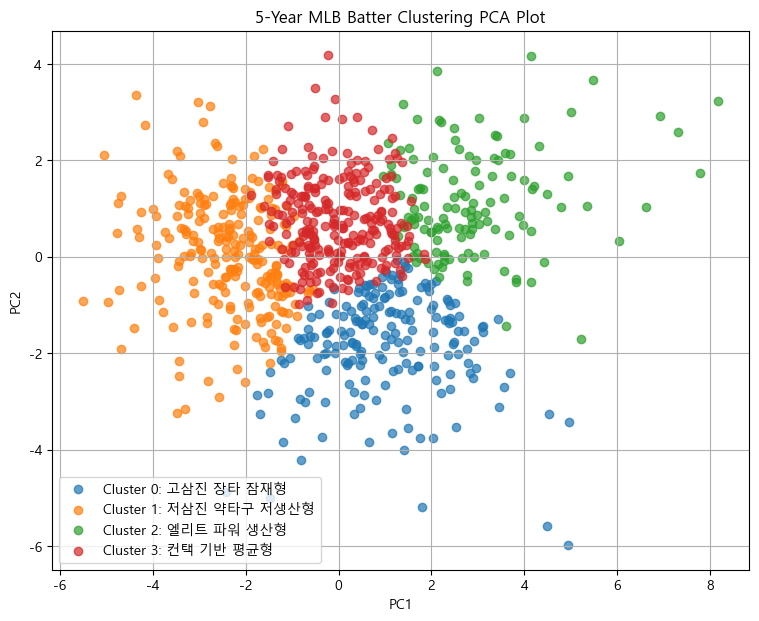

In [24]:
# PCA 산점도

plt.figure(figsize=(9, 7))

for c in sorted(pca_df_v2["cluster_k4_v2"].unique()):
    temp = pca_df_v2[pca_df_v2["cluster_k4_v2"] == c]

    plt.scatter(
        temp["PC1"],
        temp["PC2"],
        label=f"Cluster {c}: {temp['cluster_name_v2'].iloc[0]}",
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("5-Year MLB Batter Clustering PCA Plot")
plt.legend()
plt.grid(True)
plt.show()

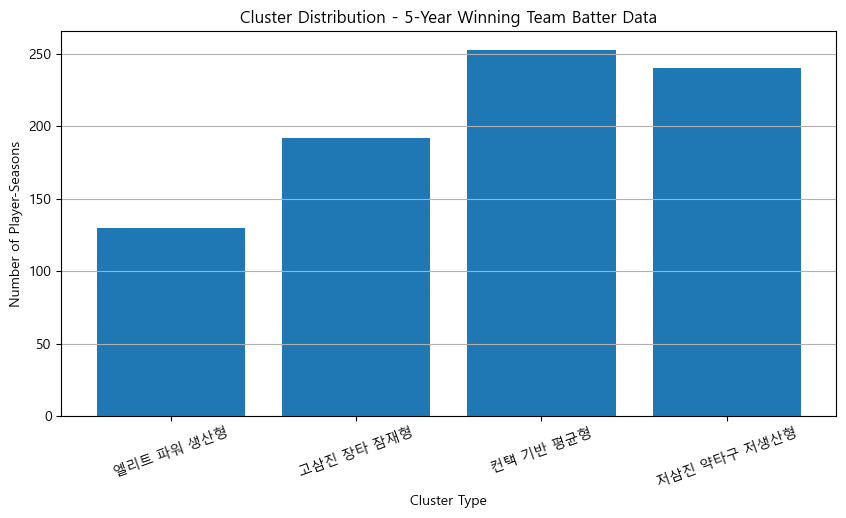

,선수 수,비율(%)
cluster_name_v2,,
엘리트 파워 생산형,130,15.95
고삼진 장타 잠재형,192,23.56
컨택 기반 평균형,253,31.04
저삼진 약타구 저생산형,240,29.45


In [25]:
# 클러스터별 선수 수 막대그래프

cluster_count = (
    batter["cluster_name_v2"]
    .value_counts()
    .reindex(cluster_order_v2)
    .fillna(0)
    .astype(int)
)

plt.figure(figsize=(10, 5))
plt.bar(cluster_count.index, cluster_count.values)

plt.xlabel("Cluster Type")
plt.ylabel("Number of Player-Seasons")
plt.title("Cluster Distribution - 5-Year Winning Team Batter Data")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

cluster_ratio = (cluster_count / cluster_count.sum() * 100).round(2)

cluster_distribution = pd.DataFrame({
    "선수 수": cluster_count,
    "비율(%)": cluster_ratio
})

cluster_distribution


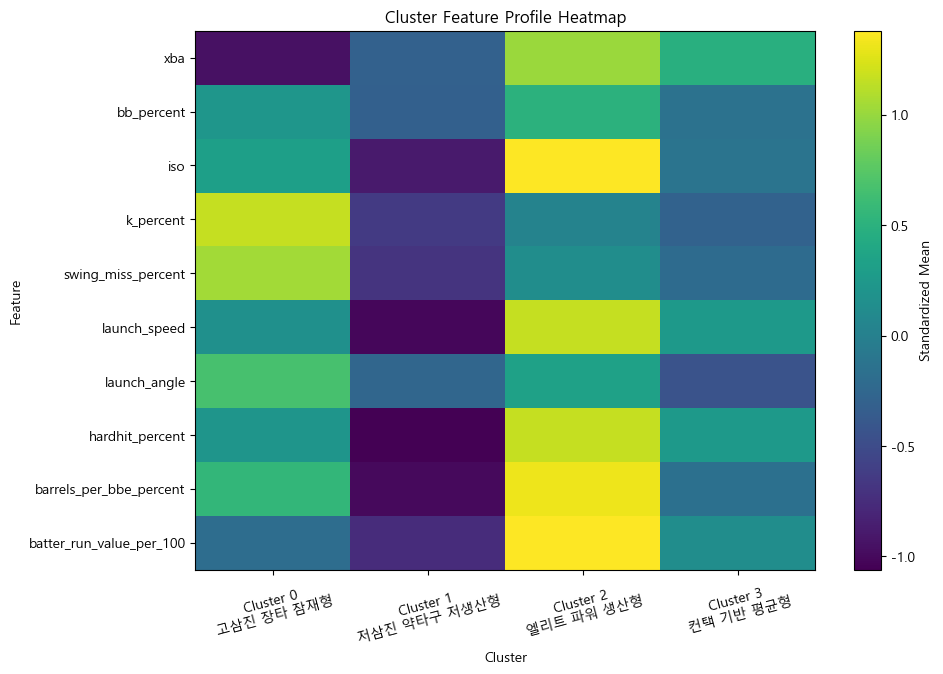

In [26]:
# 클러스터 변수 Heatmap

heatmap_data = cluster_scaled_summary_v2.T

plt.figure(figsize=(10, 7))

plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Standardized Mean")

plt.xticks(
    ticks=np.arange(len(heatmap_data.columns)),
    labels=[f"Cluster {c}\n{cluster_name_map_v2.get(c, '')}" for c in heatmap_data.columns],
    rotation=15
)

plt.yticks(
    ticks=np.arange(len(heatmap_data.index)),
    labels=heatmap_data.index
)

plt.title("Cluster Feature Profile Heatmap")
plt.xlabel("Cluster")
plt.ylabel("Feature")

plt.show()


In [27]:
# 연도별 클러스터 비율

year_cluster_ratio = pd.crosstab(
    batter["year"],
    batter["cluster_name_v2"],
    normalize="index"
) * 100

year_cluster_ratio = year_cluster_ratio.round(2)

year_cluster_ratio

cluster_name_v2,고삼진 장타 잠재형,엘리트 파워 생산형,저삼진 약타구 저생산형,컨택 기반 평균형
year,,,,
2021,23.94,21.13,25.35,29.58
2022,22.84,13.58,32.10,31.48
2023,29.17,12.50,24.40,33.93
2024,21.20,15.22,35.87,27.72
2025,20.75,18.24,28.30,32.70


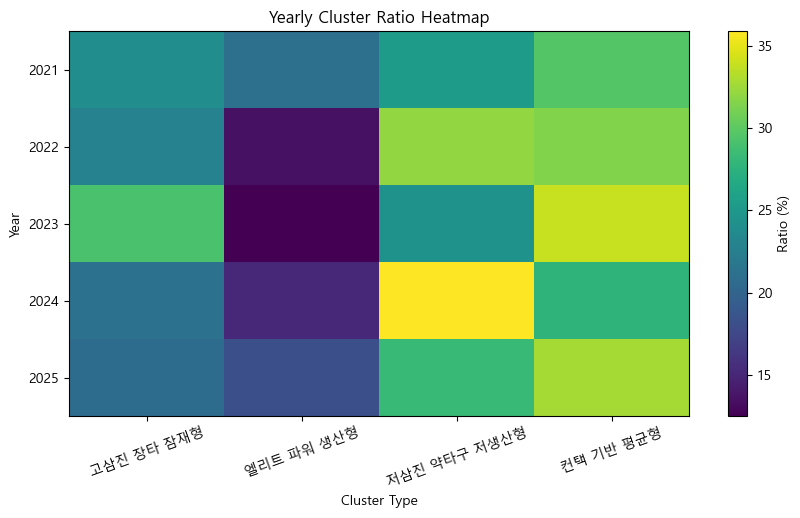

In [28]:
# 연도별 클러스터 비율 Heatmap

plt.figure(figsize=(10, 5))

plt.imshow(year_cluster_ratio, aspect="auto")
plt.colorbar(label="Ratio (%)")

plt.xticks(
    ticks=np.arange(len(year_cluster_ratio.columns)),
    labels=year_cluster_ratio.columns,
    rotation=20
)

plt.yticks(
    ticks=np.arange(len(year_cluster_ratio.index)),
    labels=year_cluster_ratio.index
)

plt.title("Yearly Cluster Ratio Heatmap")
plt.xlabel("Cluster Type")
plt.ylabel("Year")

plt.show()

In [29]:
# 팀별 클러스터 분포

team_cluster_count = pd.crosstab(
    batter["team"],
    batter["cluster_name_v2"]
)

team_cluster_ratio = pd.crosstab(
    batter["team"],
    batter["cluster_name_v2"],
    normalize="index"
) * 100

team_cluster_ratio.round(2)

cluster_name_v2,고삼진 장타 잠재형,엘리트 파워 생산형,저삼진 약타구 저생산형,컨택 기반 평균형
team,,,,
ARI,4.76,19.05,28.57,47.62
ATL,28.57,34.29,5.71,31.43
BAL,27.59,10.34,27.59,34.48
BOS,32.14,7.14,21.43,39.29
CHA,5.88,11.76,29.41,52.94
CHN,31.03,17.24,24.14,27.59
CIN,22.58,9.68,35.48,32.26
CLE,27.59,0.00,51.72,20.69
DET,25.00,15.00,25.00,35.00


In [30]:
# Miami 2021-2025 타자 데이터

from pathlib import Path
import pandas as pd

base_dir = Path(r"C:\Users\donge\OneDrive\바탕 화면\마린스 21-25 타자 데이터")

mia_batter_files = {
    2021: base_dir / "21-말린스 타자.csv",
    2022: base_dir / "22-말린스 타자.csv",
    2023: base_dir / "23-말린스 타자.csv",
    2024: base_dir / "24-말린스 타자.csv",
    2025: base_dir / "25-말린스 타자.csv"
}

mia_list = []

for year, path in mia_batter_files.items():

    temp = pd.read_csv(path, encoding="utf-8-sig")

    temp.columns = (
        temp.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )

    temp["year"] = year
    temp["team"] = "MIA"
    temp["team_group"] = "Miami"
    temp["player_name_clean"] = temp["player_name"].apply(clean_name)

    print(f"{year} Miami 원본 행 수: {len(temp)}")

    mia_list.append(temp)


# 5개년 Miami 데이터 합치기
mia_batter_raw = pd.concat(mia_list, ignore_index=True)


# PA 150 이상 필터링
mia_batter_raw["pa"] = pd.to_numeric(
    mia_batter_raw["pa"],
    errors="coerce"
)

mia_batter_pa150 = mia_batter_raw[
    mia_batter_raw["pa"] >= 150
].copy()

print("\nMiami PA 150 이상 행 수:", len(mia_batter_pa150))
print("연도별 Miami PA 150 이상 행 수:")
print(mia_batter_pa150["year"].value_counts().sort_index())


# 클러스터링 변수 선택
X_mia_v2 = mia_batter_pa150[feature_cols_v2].copy()


# 클러스터링 변수 숫자형 변환
for col in feature_cols_v2:
    X_mia_v2[col] = (
        X_mia_v2[col]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
    )

    X_mia_v2[col] = pd.to_numeric(X_mia_v2[col], errors="coerce")


# 결측치 확인
missing_feature_mia = (
    X_mia_v2
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\n클러스터링 변수별 결측치 개수:")
print(missing_feature_mia)

print("\n전체 결측치 개수:", X_mia_v2.isna().sum().sum())


# Miami 클러스터 예측
X_mia_scaled_v2 = scaler_v2.transform(X_mia_v2)

mia_batter_clustered = mia_batter_pa150.copy()

mia_batter_clustered["cluster_k4_v2"] = kmeans4_v2.predict(X_mia_scaled_v2)

mia_batter_clustered["cluster_name_v2"] = (
    mia_batter_clustered["cluster_k4_v2"]
    .map(cluster_name_map_v2)
)

mia_batter_clustered["team_group"] = "Miami"


# 결과 확인
print("\nMiami 클러스터 예측 완료 행 수:", len(mia_batter_clustered))

display(
    mia_batter_clustered[
        [
            "year",
            "team",
            "team_group",
            "player_name",
            "pa",
            "cluster_k4_v2",
            "cluster_name_v2"
        ]
    ]
    .sort_values(["year", "player_name"])
    .head(20)
)

2021 Miami 원본 행 수: 51
2022 Miami 원본 행 수: 25
2023 Miami 원본 행 수: 21
2024 Miami 원본 행 수: 29
2025 Miami 원본 행 수: 26

Miami PA 150 이상 행 수: 52
연도별 Miami PA 150 이상 행 수:
year
2021     6
2022    13
2023    12
2024    10
2025    11
Name: count, dtype: int64

클러스터링 변수별 결측치 개수:
xba                         0
bb_percent                  0
iso                         0
k_percent                   0
swing_miss_percent          0
launch_speed                0
launch_angle                0
hardhit_percent             0
barrels_per_bbe_percent     0
batter_run_value_per_100    0
dtype: int64

전체 결측치 개수: 0

Miami 클러스터 예측 완료 행 수: 52


c:\Users\donge\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


,year,team,team_group,player_name,pa,cluster_k4_v2,cluster_name_v2
1,2021,MIA,Miami,"Aguilar, Jesús",297,3,컨택 기반 평균형
3,2021,MIA,Miami,"Berti, Jon",189,1,저삼진 약타구 저생산형
2,2021,MIA,Miami,"Chisholm Jr., Jazz",280,3,컨택 기반 평균형
4,2021,MIA,Miami,"Duvall, Adam",194,0,고삼진 장타 잠재형
7,2021,MIA,Miami,"Díaz, Isan",167,1,저삼진 약타구 저생산형
0,2021,MIA,Miami,"Rojas, Miguel",331,1,저삼진 약타구 저생산형
52,2022,MIA,Miami,"Aguilar, Jesús",262,3,컨택 기반 평균형
56,2022,MIA,Miami,"Anderson, Brian",210,3,컨택 기반 평균형
54,2022,MIA,Miami,"Berti, Jon",244,1,저삼진 약타구 저생산형
61,2022,MIA,Miami,"Bleday, JJ",155,0,고삼진 장타 잠재형


In [31]:
# Miami vs 5할 이상 팀 클러스터 분포 비교

# 비교용 데이터 만들기
ref_compare = batter_ref_clustered.copy()
ref_compare["team_group"] = "5할 이상 팀"

mia_compare = mia_batter_clustered.copy()
mia_compare["team_group"] = "Miami"

compare_mia_ref = pd.concat(
    [ref_compare, mia_compare],
    ignore_index=True
)

# 클러스터별 명수표
compare_cluster_count = pd.crosstab(
    compare_mia_ref["team_group"],
    compare_mia_ref["cluster_name_v2"]
).reindex(
    index=["5할 이상 팀", "Miami"],
    columns=cluster_order_v2,
    fill_value=0
)

# 클러스터별 비율표
compare_cluster_ratio = pd.crosstab(
    compare_mia_ref["team_group"],
    compare_mia_ref["cluster_name_v2"],
    normalize="index"
).reindex(
    index=["5할 이상 팀", "Miami"],
    columns=cluster_order_v2,
    fill_value=0
) * 100

compare_cluster_ratio = compare_cluster_ratio.round(2)

display(compare_cluster_count)
display(compare_cluster_ratio)

cluster_name_v2,엘리트 파워 생산형,고삼진 장타 잠재형,컨택 기반 평균형,저삼진 약타구 저생산형
team_group,,,,
5할 이상 팀,130,192,253,240
Miami,2,10,18,22


cluster_name_v2,엘리트 파워 생산형,고삼진 장타 잠재형,컨택 기반 평균형,저삼진 약타구 저생산형
team_group,,,,
5할 이상 팀,15.95,23.56,31.04,29.45
Miami,3.85,19.23,34.62,42.31


In [32]:
# Miami vs 5할 이상 팀의 연도별 클러스터 분포 비교

year_group_cluster_count = pd.crosstab(
    [compare_mia_ref["team_group"], compare_mia_ref["year"]],
    compare_mia_ref["cluster_name_v2"]
).reindex(
    columns=cluster_order_v2,
    fill_value=0
).sort_index()

year_group_cluster_ratio = pd.crosstab(
    [compare_mia_ref["team_group"], compare_mia_ref["year"]],
    compare_mia_ref["cluster_name_v2"],
    normalize="index"
).reindex(
    columns=cluster_order_v2,
    fill_value=0
).sort_index() * 100

year_group_cluster_ratio = year_group_cluster_ratio.round(2)

display(year_group_cluster_count)
display(year_group_cluster_ratio)

cluster_name_v2  엘리트 파워 생산형  고삼진 장타 잠재형  컨택 기반 평균형  저삼진 약타구 저생산형
team_group year                                                 
5할 이상 팀    2021          30          34         42            36
           2022          22          37         51            52
           2023          21          49         57            41
           2024          28          39         51            66
           2025          29          33         52            45
Miami      2021           0           1          2             3
           2022           0           3          6             4
           2023           1           3          1             7
           2024           0           1          5             4
           2025           1           2          4             4

cluster_name_v2  엘리트 파워 생산형  고삼진 장타 잠재형  컨택 기반 평균형  저삼진 약타구 저생산형
team_group year                                                 
5할 이상 팀    2021       21.13       23.94      29.58         25.35
           2022       13.58       22.84      31.48         32.10
           2023       12.50       29.17      33.93         24.40
           2024       15.22       21.20      27.72         35.87
           2025       18.24       20.75      32.70         28.30
Miami      2021        0.00       16.67      33.33         50.00
           2022        0.00       23.08      46.15         30.77
           2023        8.33       25.00       8.33         58.33
           2024        0.00       10.00      50.00         40.00
           2025        9.09       18.18      36.36         36.36

In [33]:
# Miami vs 5할 이상 팀 클러스터 차이 비교

compare_summary = pd.DataFrame({
    "Miami 명수": compare_cluster_count.loc["Miami"],
    "5할 이상 팀 명수": compare_cluster_count.loc["5할 이상 팀"],
    "Miami 비율(%)": compare_cluster_ratio.loc["Miami"],
    "5할 이상 팀 비율(%)": compare_cluster_ratio.loc["5할 이상 팀"],
    "차이(%p)": (
        compare_cluster_ratio.loc["Miami"]
        - compare_cluster_ratio.loc["5할 이상 팀"]
    )
}).round(2)

compare_summary = compare_summary.sort_values("차이(%p)")

display(compare_summary)

,Miami 명수,5할 이상 팀 명수,Miami 비율(%),5할 이상 팀 비율(%),차이(%p)
cluster_name_v2,,,,,
엘리트 파워 생산형,2,130,3.85,15.95,-12.10
고삼진 장타 잠재형,10,192,19.23,23.56,-4.33
컨택 기반 평균형,18,253,34.62,31.04,3.58
저삼진 약타구 저생산형,22,240,42.31,29.45,12.86


In [34]:
# PA 기준 민감도 분석
# 위의 (Miami vs 5할 이상 팀) 분석은 PA 150 이상 기준으로 진행하였으나 Miami 표본 수가 상대적으로 작으므로, PA 50, PA 100 기준에서도 같은 scaler_v2와 kmeans4_v2를 적용하여 클러스터 분포 방향이 크게 달라지는지 보조적으로 확인한다.
# 민감도 분석에서는 클러스터링 모델을 새로 fit하지 않고, 기존 5할 이상 팀 PA150 기준 모델에 predict만 수행한다.

def assign_cluster_for_sensitivity(df, pa_cut, team_group):
    temp = df.copy()

    temp["pa"] = pd.to_numeric(temp["pa"], errors="coerce")
    temp = temp[temp["pa"] >= pa_cut].copy()

    if team_group == "5할 이상 팀":
        temp["team"] = temp["team"].apply(
            lambda x: np.nan if pd.isna(x) else str(x).strip().upper()
        )
        temp["is_win500_team"] = temp.apply(
            lambda row: row["team"] in win500_teams_by_year.get(row["year"], []),
            axis=1
        )
        temp = temp[
            (temp["is_win500_team"]) &
            (temp["team"] != "MIA")
        ].copy()

    temp["team_group"] = team_group

    X_temp = temp[feature_cols_v2].copy()

    for col in feature_cols_v2:
        X_temp[col] = (
            X_temp[col]
            .astype(str)
            .str.replace("%", "", regex=False)
            .str.replace(",", "", regex=False)
        )
        X_temp[col] = pd.to_numeric(X_temp[col], errors="coerce")

    valid_mask = X_temp.notna().all(axis=1)
    temp = temp.loc[valid_mask].copy()
    X_temp = X_temp.loc[valid_mask].copy()

    X_scaled = scaler_v2.transform(X_temp)
    temp["cluster_k4_v2"] = kmeans4_v2.predict(X_scaled)
    temp["cluster_name_v2"] = temp["cluster_k4_v2"].map(cluster_name_map_v2)

    return temp

sensitivity_results = []
sensitivity_tables = {}

for pa_cut in [50, 100, 150]:
    ref_sens = assign_cluster_for_sensitivity(
        batter_5yr,
        pa_cut=pa_cut,
        team_group="5할 이상 팀"
    )

    mia_sens = assign_cluster_for_sensitivity(
        mia_batter_raw,
        pa_cut=pa_cut,
        team_group="Miami"
    )

    sens_compare = pd.concat([ref_sens, mia_sens], ignore_index=True)

    sens_count = pd.crosstab(
        sens_compare["team_group"],
        sens_compare["cluster_name_v2"]
    ).reindex(
        index=["5할 이상 팀", "Miami"],
        columns=cluster_order_v2,
        fill_value=0
    )

    sens_ratio = pd.crosstab(
        sens_compare["team_group"],
        sens_compare["cluster_name_v2"],
        normalize="index"
    ).reindex(
        index=["5할 이상 팀", "Miami"],
        columns=cluster_order_v2,
        fill_value=0
    ) * 100

    sens_ratio = sens_ratio.round(2)

    sensitivity_results.append({
        "pa_cut": pa_cut,
        "ref_n": len(ref_sens),
        "mia_n": len(mia_sens)
    })

    sensitivity_tables[pa_cut] = {
        "count": sens_count,
        "ratio": sens_ratio
    }

pa_sensitivity_summary = pd.DataFrame(sensitivity_results)

display(pa_sensitivity_summary)

for pa_cut in [50, 100, 150]:
    print(f"\n[PA {pa_cut} 이상 클러스터 비율]")
    display(sensitivity_tables[pa_cut]["ratio"])


c:\Users\donge\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
c:\Users\donge\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
c:\Users\donge\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
c:\Users\donge\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
c:\Users\donge\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have vali

,pa_cut,ref_n,mia_n
0,50,1215,91
1,100,990,72
2,150,812,52



[PA 50 이상 클러스터 비율]


cluster_name_v2,엘리트 파워 생산형,고삼진 장타 잠재형,컨택 기반 평균형,저삼진 약타구 저생산형
team_group,,,,
5할 이상 팀,12.51,27.65,24.77,35.06
Miami,4.40,26.37,26.37,42.86



[PA 100 이상 클러스터 비율]


cluster_name_v2,엘리트 파워 생산형,고삼진 장타 잠재형,컨택 기반 평균형,저삼진 약타구 저생산형
team_group,,,,
5할 이상 팀,14.24,25.76,28.08,31.92
Miami,5.56,20.83,31.94,41.67



[PA 150 이상 클러스터 비율]


cluster_name_v2,엘리트 파워 생산형,고삼진 장타 잠재형,컨택 기반 평균형,저삼진 약타구 저생산형
team_group,,,,
5할 이상 팀,16.01,23.40,31.03,29.56
Miami,3.85,19.23,34.62,42.31


In [35]:
# Miami vs 5할 이상 팀 변수 평균 비교

compare_feature_df = compare_mia_ref.copy()

# 클러스터링 변수 숫자형 변환
for col in feature_cols_v2:
    compare_feature_df[col] = (
        compare_feature_df[col]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
    )
    compare_feature_df[col] = pd.to_numeric(compare_feature_df[col], errors="coerce")

# 원자료 기준 평균 비교
group_feature_mean_raw = (
    compare_feature_df
    .groupby("team_group")[feature_cols_v2]
    .mean()
    .reindex(["5할 이상 팀", "Miami"])
    .round(3)
)

# scaler 기준 평균 비교
X_compare_scaled = pd.DataFrame(
    scaler_v2.transform(compare_feature_df[feature_cols_v2]),
    columns=feature_cols_v2,
    index=compare_feature_df.index
)

X_compare_scaled["team_group"] = compare_feature_df["team_group"]

group_feature_mean_z = (
    X_compare_scaled
    .groupby("team_group")[feature_cols_v2]
    .mean()
    .reindex(["5할 이상 팀", "Miami"])
    .round(2)
)

# Miami - 5할 이상 팀
miami_feature_diff_z = (
    group_feature_mean_z.loc["Miami"]
    - group_feature_mean_z.loc["5할 이상 팀"]
).sort_values(ascending=False)

display(group_feature_mean_raw.T)
display(group_feature_mean_z.T)
display(miami_feature_diff_z.head(5).to_frame("Miami - 5할 이상 팀"))
display(miami_feature_diff_z.tail(5).to_frame("Miami - 5할 이상 팀"))

team_group,5할 이상 팀,Miami
xba,0.265,0.261
bb_percent,10.414,9.308
iso,0.186,0.154
k_percent,18.041,17.567
swing_miss_percent,19.416,18.788
launch_speed,90.304,89.590
launch_angle,14.200,11.131
hardhit_percent,45.126,42.603
barrels_per_bbe_percent,9.679,8.022
batter_run_value_per_100,0.300,-0.199


team_group,5할 이상 팀,Miami
xba,-0.0,-0.13
bb_percent,-0.0,-0.33
iso,0.0,-0.48
k_percent,-0.0,-0.08
swing_miss_percent,0.0,-0.11
launch_speed,-0.0,-0.25
launch_angle,0.0,-0.56
hardhit_percent,-0.0,-0.29
barrels_per_bbe_percent,0.0,-0.33
batter_run_value_per_100,-0.0,-0.52


,Miami - 5할 이상 팀
k_percent,-0.08
swing_miss_percent,-0.11
xba,-0.13
launch_speed,-0.25
hardhit_percent,-0.29


,Miami - 5할 이상 팀
bb_percent,-0.33
barrels_per_bbe_percent,-0.33
iso,-0.48
batter_run_value_per_100,-0.52
launch_angle,-0.56


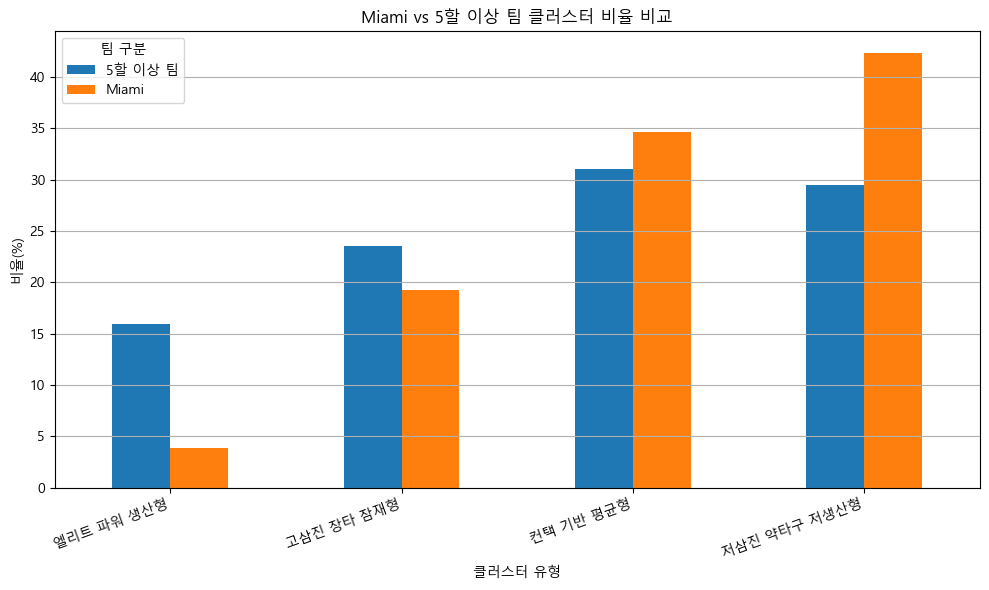

In [36]:
# Miami vs 5할 이상 팀 클러스터 비율 막대그래프

ax = compare_cluster_ratio.T.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_xlabel("클러스터 유형")
ax.set_ylabel("비율(%)")
ax.set_title("Miami vs 5할 이상 팀 클러스터 비율 비교")

plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")
plt.legend(title="팀 구분")
plt.tight_layout()
plt.show()

In [37]:
# Teams.csv(회귀분석용 팀 성적 데이터)

teams = pd.read_csv(
    r"C:/Users/donge/OneDrive/바탕 화면/마린스 21-25 타자 데이터/Teams.csv"
)

# 2021~2025 시즌만 사용
teams = teams[teams["yearID"].between(2021, 2025)].copy()

# 승률과 득점 변수 생성
teams["win_pct"] = teams["W"] / (teams["W"] + teams["L"])
teams["runs_scored"] = teams["R"]

# 컬럼명 통일
team_result = teams[
    ["yearID", "teamID", "W", "L", "win_pct", "runs_scored"]
].copy()

team_result = team_result.rename(
    columns={
        "yearID": "year",
        "teamID": "team"
    }
)

team_result.head()

,year,team,W,L,win_pct,runs_scored
3464,2021,ARI,52,110,0.320988,679.0
3465,2021,ATL,88,73,0.546584,790.0
3466,2021,BAL,52,110,0.320988,659.0
3467,2021,BOS,92,70,0.567901,829.0
3468,2021,CHA,93,69,0.574074,796.0


In [38]:
# 팀-시즌별 클러스터 비율 만들기

reg_batter = batter_ref_clustered.copy()

team_cluster_wide = pd.crosstab(
    [reg_batter["year"], reg_batter["team"]],
    reg_batter["cluster_name_v2"],
    normalize="index"
).reindex(
    columns=cluster_order_v2,
    fill_value=0
).reset_index()

team_cluster_wide.columns.name = None

team_cluster_wide = team_cluster_wide.rename(columns={
    "고삼진 장타 잠재형": "ratio_highK_power_potential",
    "저삼진 약타구 저생산형": "ratio_low_prod_weak_contact",
    "엘리트 파워 생산형": "ratio_elite_power",
    "컨택 기반 평균형": "ratio_contact_avg"
})

team_cluster_wide.head()

,year,team,ratio_elite_power,ratio_highK_power_potential,ratio_contact_avg,ratio_low_prod_weak_contact
0,2021,ATL,0.166667,0.333333,0.333333,0.166667
1,2021,BOS,0.111111,0.222222,0.444444,0.222222
2,2021,CHA,0.166667,0.000000,0.666667,0.166667
3,2021,CIN,0.333333,0.111111,0.333333,0.222222
4,2021,HOU,0.181818,0.181818,0.363636,0.272727


In [39]:
# 회귀분석용 데이터 merge

reg_data = team_cluster_wide.merge(
    team_result,
    on=["year", "team"],
    how="inner",
    validate="1:1"
)

print("회귀분석용 팀-시즌 수:", len(reg_data))
print("승률 결측:", reg_data["win_pct"].isna().sum())
print("득점 결측:", reg_data["runs_scored"].isna().sum())

reg_data.head()

회귀분석용 팀-시즌 수: 82
승률 결측: 0
득점 결측: 0


,year,team,ratio_elite_power,ratio_highK_power_potential,ratio_contact_avg,ratio_low_prod_weak_contact,W,L,win_pct,runs_scored
0,2021,ATL,0.166667,0.333333,0.333333,0.166667,88,73,0.546584,790.0
1,2021,BOS,0.111111,0.222222,0.444444,0.222222,92,70,0.567901,829.0
2,2021,CHA,0.166667,0.000000,0.666667,0.166667,93,69,0.574074,796.0
3,2021,CIN,0.333333,0.111111,0.333333,0.222222,83,79,0.512346,786.0
4,2021,HOU,0.181818,0.181818,0.363636,0.272727,95,67,0.586420,863.0


In [40]:
# %pip install statsmodels

import statsmodels.api as sm

In [41]:
# 득점 회귀분석
# 기준집단: 저삼진 약타구 저생산형
# 아래 회귀계수들은 기준집단인 '저삼진 약타구 저생산형' 대비 효과로 해석함.

X_cols = [
    "ratio_highK_power_potential",
    "ratio_elite_power",
    "ratio_contact_avg"
]

reg_model_data = reg_data.dropna(
    subset=X_cols + ["runs_scored"]
).copy()

X = reg_model_data[X_cols]
X = sm.add_constant(X)

y_runs = reg_model_data["runs_scored"]

model_runs = sm.OLS(y_runs, X).fit()

print(model_runs.summary())

                            OLS Regression Results                            
Dep. Variable:            runs_scored   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     13.10
Date:                Thu, 21 May 2026   Prob (F-statistic):           5.19e-07
Time:                        11:51:23   Log-Likelihood:                -438.83
No. Observations:                  82   AIC:                             885.7
Df Residuals:                      78   BIC:                             895.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [42]:
# 10%p 증가 시 득점 변화량 

coef_interpret = model_runs.params[X_cols].to_frame("회귀계수")

coef_interpret["10%p 증가 시 득점 변화"] = (
    coef_interpret["회귀계수"] * 0.1
)

coef_interpret = coef_interpret.round(2)

coef_interpret

,회귀계수,10%p 증가 시 득점 변화
ratio_highK_power_potential,114.68,11.47
ratio_elite_power,308.77,30.88
ratio_contact_avg,169.80,16.98


In [43]:
# 회귀분석 결과 해석
# 종속변수: 팀 득점(runs_scored)
# 독립변수: 팀-시즌별 타자 클러스터 비율

# 모형 전체 결과:
# R-squared = 0.335, Adj. R-squared = 0.309
# 즉, 타자 클러스터 구성 비율만으로 팀 득점 변동의 약 33.5%를 설명한다.
# F-statistic의 p-value = 5.19e-07로 매우 작으므로, 모형 전체는 통계적으로 유의하다고 볼 수 있다.

# 1) 고삼진 장타 잠재형
# coef = 114.6814, p-value = 0.018
# 고삼진 장타 잠재형 비율은 팀 득점과 유의한 양의 관계를 보인다.
# 이 유형의 비율이 10%p 증가하면, 팀 득점은 약 11.47점 증가하는 경향이 있다.

# 2) 엘리트 파워 생산형
# coef = 308.7703, p-value < 0.001
# 엘리트 파워 생산형 비율은 팀 득점과 매우 강한 양의 관계를 보인다.
# 이 유형의 비율이 10%p 증가하면, 팀 득점은 약 30.88점 증가하는 경향이 있다.
# 세 클러스터 중 득점 증가 효과가 가장 크게 나타났다.

# 3) 컨택 기반 평균형
# coef = 169.7987, p-value < 0.001
# 컨택 기반 평균형 비율도 팀 득점과 유의한 양의 관계를 보인다.
# 이 유형의 비율이 10%p 증가하면, 팀 득점은 약 16.98점 증가하는 경향이 있다.

# 종합 해석: 기준집단인 '저삼진 약타구 저생산형'에 비해 고삼진 장타 잠재형, 엘리트 파워 생산형, 컨택 기반 평균형은 모두 팀 득점에 긍정적인 관계를 보였다.
# 특히 엘리트 파워 생산형의 계수가 가장 크므로, Miami가 이 유형의 비중이 낮다면 장타력과 타구 생산성이 높은 타자를 우선적으로 보강할 필요가 있다.

In [44]:
# 최종 결과 저장

batter_ref_clustered.to_csv(
    "batter_ref_win500_exclude_miami_cluster_result.csv",
    index=False,
    encoding="utf-8-sig"
)

mia_batter_clustered.to_csv(
    "batter_miami_2021_2025_cluster_result.csv",
    index=False,
    encoding="utf-8-sig"
)

compare_mia_ref.to_csv(
    "batter_compare_miami_vs_win500_cluster_result.csv",
    index=False,
    encoding="utf-8-sig"
)

compare_summary.to_csv(
    "batter_compare_cluster_summary.csv",
    index=True,
    encoding="utf-8-sig"
)

reg_data.to_csv(
    "batter_cluster_team_season_regression_data.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료")

저장 완료


In [45]:
# 연봉 merge용 이름/팀 정리 함수

import re
import unicodedata
import pandas as pd

def make_name_key(name):
    if pd.isna(name):
        return ""

    s = str(name).strip()

    # "Crawford, J.P." -> "J.P. Crawford"
    if "," in s:
        last, first = s.split(",", 1)
        s = first.strip() + " " + last.strip()

    # 악센트 제거: José -> Jose
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))

    s = s.lower()

    # jr, sr, ii 같은 suffix 제거
    s = re.sub(r"\b(jr|sr|ii|iii|iv)\b", "", s)

    # 문자/숫자만 남김
    s = re.sub(r"[^a-z0-9]", "", s)

    return s


def make_team_key(team):
    if pd.isna(team):
        return ""

    raw = str(team).strip()
    s = raw.upper()
    lower = raw.lower()

    team_map = {
        "ANA": "LAA", "ARI": "ARI", "ATL": "ATL", "BAL": "BAL", "BOS": "BOS",
        "CHA": "CHW", "CHW": "CHW", "CWS": "CHW", "CHN": "CHC", "CHC": "CHC",
        "CIN": "CIN", "CLE": "CLE", "COL": "COL", "DET": "DET", "HOU": "HOU",
        "KCA": "KCR", "KC": "KCR", "KCR": "KCR", "LAA": "LAA",
        "LAN": "LAD", "LA": "LAD", "LAD": "LAD", "MIA": "MIA", "MIL": "MIL",
        "MIN": "MIN", "NYA": "NYY", "NYY": "NYY", "NYN": "NYM", "NYM": "NYM",
        "OAK": "OAK", "PHI": "PHI", "PIT": "PIT", "SD": "SDP", "SDN": "SDP",
        "SDP": "SDP", "SEA": "SEA", "SF": "SFG", "SFN": "SFG", "SFG": "SFG",
        "SLN": "STL", "STL": "STL", "TB": "TBR", "TBA": "TBR", "TBR": "TBR",
        "TEX": "TEX", "TOR": "TOR", "WAS": "WSN", "WSH": "WSN", "WSN": "WSN"
    }

    full_team_map = {
        "angels": "LAA", "astros": "HOU", "athletics": "OAK", "blue jays": "TOR",
        "braves": "ATL", "brewers": "MIL", "cardinals": "STL", "cubs": "CHC",
        "diamondbacks": "ARI", "dodgers": "LAD", "giants": "SFG", "guardians": "CLE",
        "mariners": "SEA", "marlins": "MIA", "mets": "NYM", "nationals": "WSN",
        "orioles": "BAL", "padres": "SDP", "phillies": "PHI", "pirates": "PIT",
        "rangers": "TEX", "rays": "TBR", "red sox": "BOS", "reds": "CIN",
        "rockies": "COL", "royals": "KCR", "tigers": "DET", "twins": "MIN",
        "white sox": "CHW", "yankees": "NYY"
    }

    if s in team_map:
        return team_map[s]
    if lower in full_team_map:
        return full_team_map[lower]
    return s


In [46]:
import numpy as np
from pathlib import Path

# 클러스터별 회귀 효과 정리

cluster_ratio_col_map = {
    "고삼진 장타 잠재형": "ratio_highK_power_potential",
    "엘리트 파워 생산형": "ratio_elite_power",
    "컨택 기반 평균형": "ratio_contact_avg",
    "저삼진 약타구 저생산형": None
}

cluster_reg_score = []

for_cluster_names = compare_summary.index.tolist()

for cluster_name in for_cluster_names:
    ratio_col = cluster_ratio_col_map.get(cluster_name)

    if ratio_col is None:
        runs_estimate = np.nan
        runs_pvalue = np.nan
    else:
        runs_estimate = model_runs.params.get(ratio_col, np.nan)
        runs_pvalue = model_runs.pvalues.get(ratio_col, np.nan)

    cluster_reg_score.append({
        "cluster_name_v2": cluster_name,
        "ratio_col": ratio_col,
        "runs_estimate": runs_estimate,
        "runs_pvalue": runs_pvalue
    })

cluster_reg_score = pd.DataFrame(cluster_reg_score)

# Miami 부족 클러스터 & 추천 클러스터 선정

mia_need_cluster_batter = compare_summary.reset_index().rename(
    columns={"index": "cluster_name_v2"}
)

mia_need_cluster_batter["need_type"] = np.where(
    mia_need_cluster_batter["차이(%p)"] < 0,
    "MIA 부족",
    np.where(
        mia_need_cluster_batter["차이(%p)"] > 0,
        "MIA 과잉",
        "비슷"
    )
)

mia_need_cluster_batter["shortage_score"] = np.where(
    mia_need_cluster_batter["차이(%p)"] < 0,
    mia_need_cluster_batter["차이(%p)"].abs(),
    0
)

mia_need_cluster_batter = mia_need_cluster_batter.merge(
    cluster_reg_score,
    on="cluster_name_v2",
    how="left"
)

mia_need_cluster_batter["cluster_quality"] = mia_need_cluster_batter["cluster_name_v2"].map({
    "엘리트 파워 생산형": "elite",
    "고삼진 장타 잠재형": "good_potential",
    "컨택 기반 평균형": "middle",
    "저삼진 약타구 저생산형": "bad"
})

mia_need_cluster_batter["recommend_cluster"] = np.where(
    (mia_need_cluster_batter["need_type"] == "MIA 부족") &
    (mia_need_cluster_batter["cluster_quality"] != "bad") &
    (mia_need_cluster_batter["runs_estimate"] > 0) &
    (mia_need_cluster_batter["runs_pvalue"] < 0.10),
    "최우선 보강",
    np.where(
        (mia_need_cluster_batter["need_type"] == "MIA 부족") &
        (mia_need_cluster_batter["cluster_quality"] != "bad"),
        "보강 후보",
        "비추천 또는 낮은 우선순위"
    )
)

mia_need_cluster_batter = mia_need_cluster_batter.sort_values(
    "shortage_score",
    ascending=False
)

# 최종 추천 대상 클러스터

target_clusters_batter = mia_need_cluster_batter[
    mia_need_cluster_batter["recommend_cluster"].isin(["최우선 보강", "보강 후보"])
][
    [
        "cluster_name_v2",
        "need_type",
        "차이(%p)",
        "shortage_score",
        "cluster_quality",
        "recommend_cluster",
        "runs_estimate",
        "runs_pvalue"
    ]
].copy()

display(mia_need_cluster_batter)
display(target_clusters_batter)

,cluster_name_v2,Miami 명수,5할 이상 팀 명수,Miami 비율(%),5할 이상 팀 비율(%),차이(%p),need_type,shortage_score,ratio_col,runs_estimate,runs_pvalue,cluster_quality,recommend_cluster
0,엘리트 파워 생산형,2,130,3.85,15.95,-12.10,MIA 부족,12.10,ratio_elite_power,308.770337,5.532748e-08,elite,최우선 보강
1,고삼진 장타 잠재형,10,192,19.23,23.56,-4.33,MIA 부족,4.33,ratio_highK_power_potential,114.681384,1.753545e-02,good_potential,최우선 보강
2,컨택 기반 평균형,18,253,34.62,31.04,3.58,MIA 과잉,0.00,ratio_contact_avg,169.798706,3.616881e-04,middle,비추천 또는 낮은 우선순위
3,저삼진 약타구 저생산형,22,240,42.31,29.45,12.86,MIA 과잉,0.00,NaN,NaN,NaN,bad,비추천 또는 낮은 우선순위


,cluster_name_v2,need_type,차이(%p),shortage_score,cluster_quality,recommend_cluster,runs_estimate,runs_pvalue
0,엘리트 파워 생산형,MIA 부족,-12.10,12.10,elite,최우선 보강,308.770337,5.532748e-08
1,고삼진 장타 잠재형,MIA 부족,-4.33,4.33,good_potential,최우선 보강,114.681384,1.753545e-02


In [47]:
# 영입 후보 선정 기준
# 본 분석의 목적은 Miami Marlins가 5할 이상 팀 대비 부족한 타자 유형을 보강하기 위해, 2025년 기준 저비용·고효율 타자 후보를 선별하는 것이다.

# 1) 영입 후보 선정 흐름
# - 2021~2025년 5할 이상 팀 타자 데이터를 기준으로 KMeans 클러스터링을 수행하였다.
# - Miami 타자들은 같은 scaler와 KMeans 모델에 배정하여 5할 이상 팀과 클러스터 비율을 비교하였다.
# - Miami 비율이 5할 이상 팀보다 낮은 클러스터를 Miami에 부족한 유형으로 정의하였다.
# - 회귀분석 결과를 활용하여 Miami에 부족하면서도 팀 득점과 양의 관계를 보이는 클러스터를 추천 대상 클러스터로 선정하였다.
# - 영입 후보 탐색 범위는 2025년 전체 MLB 타자(Miami 선수 제외)로 확장하였다.
# - 2025년 연봉 데이터를 병합한 뒤, 성과·비용·안정성을 점수화하여 최종 후보 우선순위를 산출하였다.

# 2) 후보군이 이미 통과한 기준
# 기준 1. PA 150 이상
# - 전체 MLB 타자 데이터를 불러온 뒤 PA 150 이상 선수만 대상으로 클러스터를 예측하였다.
# - PA가 너무 적은 선수는 xBA, ISO, HardHit%, Barrel% 등의 지표가 표본 수 문제로 불안정할 수 있기 때문이다.
# - 다만 Miami 표본 수가 줄어드는 한계가 있으므로, PA 50/100 기준 민감도 분석을 보조적으로 확인하였다.
# 기준 2. Miami 부족 추천 클러스터
# - candidate_2025는 이미 target_clusters_batter에 속한 선수만 남긴 데이터이다.
# - target_clusters_batter는 Miami에 부족하고, 회귀분석에서 득점과 긍정적인 관계를 보인 클러스터를 기준으로 만들었다.

# 3) 점수제도 구성
# total_score = performance_score + cost_score + reliability_score
# performance_score:
# - 선수의 타격 생산성과 타구 질을 평가한다.
# - 반영 지표: xBA, ISO, HardHit%, Barrel%, batter_run_value_per_100
# - 최근 3년 가중 성과 점수를 사용하였다.
# - 최근 3년 가중치: 2023년 0.2, 2024년 0.3, 2025년 0.5
# - 최근 시즌일수록 현재 기량을 더 잘 반영한다고 보고 높은 가중치를 부여하였다.
# cost_score:
# - 연봉 부담과 연봉 대비 생산성을 평가한다.
# - salary_score는 같은 클러스터 내 연봉 분위수를 기준으로 계산하였다.
#   salary <= Q1: 3점, salary <= median: 2점, salary <= Q3: 1점, salary > Q3: 0점
# - value_score는 recent_run_value_per_1m을 기준으로 연봉 대비 생산성이 좋은 선수를 높게 평가하였다.
# reliability_score:
# - 선수의 출전 안정성과 지표 신뢰도를 평가한다.
# - 최근 3년 누적 PA 기반 점수를 사용하였다.

# 4) 최종 후보 해석
# 최종 후보는 단순히 성적이 가장 좋은 선수가 아니다.
# 이미 Miami에 부족한 추천 클러스터에 속한 선수들 중에서, performance_score, cost_score, reliability_score를 합산한 total_score가 높은 선수를 우선 추천한다.
# 최종 추천 선수는 'Miami의 부족 유형을 보완할 수 있는 저비용·고효율 타자 후보'로 해석한다.
# 단, 본 분석은 실제 트레이드 가능성, 계약 기간, 수비 포지션, 팀 상황, 부상 이력, FA 여부 등을 모두 반영한 것은 아니므로, 최종 영입 판단보다는 데이터 기반 1차 후보군 선별로 해석해야 한다.

In [50]:
# 전체 MLB 2023~2025 타자 데이터 불러오기 + 기준 모델로 클러스터 예측

base_dir = Path(r"C:\Users\donge\OneDrive\바탕 화면\마린스 21-25 타자 데이터")

all_batter_files = {
    2021: base_dir / "21-전체 타자.csv",
    2022: base_dir / "22-전체 타자.csv",
    2023: base_dir / "23-전체 타자.csv",
    2024: base_dir / "24-전체 타자.csv",
    2025: base_dir / "25-전체 타자.csv"
}

all_list = []

for year, path in all_batter_files.items():
    temp = pd.read_csv(path, encoding="utf-8-sig")

    temp.columns = (
        temp.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )

    temp["year"] = year
    temp["player_name_clean"] = temp["player_name"].apply(clean_name)
    temp["name_key"] = temp["player_name"].apply(make_name_key)

    all_list.append(temp)

batter_all_raw = pd.concat(all_list, ignore_index=True)

batter_all_raw["pa"] = pd.to_numeric(batter_all_raw["pa"], errors="coerce")
batter_all_pa150 = batter_all_raw[batter_all_raw["pa"] >= 150].copy()

X_all_v2 = batter_all_pa150[feature_cols_v2].copy()

for col in feature_cols_v2:
    X_all_v2[col] = (
        X_all_v2[col]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
    )
    X_all_v2[col] = pd.to_numeric(X_all_v2[col], errors="coerce")

valid_all_mask_v2 = X_all_v2.notna().all(axis=1)

batter_all_clustered = batter_all_pa150.loc[valid_all_mask_v2].copy()
X_all_v2 = X_all_v2.loc[valid_all_mask_v2].copy()

X_all_scaled_v2 = scaler_v2.transform(X_all_v2)

batter_all_clustered["cluster_k4_v2"] = kmeans4_v2.predict(X_all_scaled_v2)
batter_all_clustered["cluster_name_v2"] = batter_all_clustered["cluster_k4_v2"].map(cluster_name_map_v2)

print("전체 MLB 2021~2025 클러스터 배정 완료:", len(batter_all_clustered))
print("연도별 행 수")
print(batter_all_clustered["year"].value_counts().sort_index())

display(
    batter_all_clustered[
        ["year", "player_name", "pa", "cluster_k4_v2", "cluster_name_v2"]
    ].head(20)
)


전체 MLB 2021~2025 클러스터 배정 완료: 1515
연도별 행 수
year
2021    290
2022    307
2023    312
2024    311
2025    295
Name: count, dtype: int64


c:\Users\donge\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


,year,player_name,pa,cluster_k4_v2,cluster_name_v2
0,2021,"Lowe, Nathaniel",421.0,3,컨택 기반 평균형
1,2021,"Crawford, J.P.",422.0,1,저삼진 약타구 저생산형
2,2021,"Straw, Myles",420.0,1,저삼진 약타구 저생산형
3,2021,"LeMahieu, DJ",377.0,3,컨택 기반 평균형
4,2021,"Chapman, Matt",385.0,0,고삼진 장타 잠재형
5,2021,"Grossman, Robbie",399.0,0,고삼진 장타 잠재형
6,2021,"Devers, Rafael",395.0,0,고삼진 장타 잠재형
7,2021,"Semien, Marcus",454.0,2,엘리트 파워 생산형
8,2021,"Freeman, Freddie",422.0,3,컨택 기반 평균형
9,2021,"Olson, Matt",382.0,2,엘리트 파워 생산형


In [58]:
# Standard Batting 데이터에서 WAR merge
# batter_all_clustered에 war 변수 추가


war_files = {
    2021: base_dir / "21-Standard Batting.txt",
    2022: base_dir / "22-Standard Batting.txt",
    2023: base_dir / "23-Standard Batting.txt",
    2024: base_dir / "24-Standard Batting.txt",
    2025: base_dir / "25-Standard Batting.txt"
}

war_list = []

for year, path in war_files.items():
    temp = pd.read_csv(path, encoding="utf-8-sig")
    
    temp.columns = temp.columns.astype(str).str.strip()
    
    # Baseball-Reference 파일에 중간 헤더 행이 섞여 있을 경우 제거
    temp = temp[temp["Player"].astype(str) != "Player"].copy()
    
    temp["year"] = year
    temp["name_key"] = temp["Player"].apply(make_name_key)
    temp["war"] = pd.to_numeric(temp["WAR"], errors="coerce")
    
    temp["bref_id"] = temp["Player-additional"]
    temp["bref_team"] = temp["Team"]
    temp["bref_pa"] = pd.to_numeric(temp["PA"], errors="coerce")
    temp["bref_g"] = pd.to_numeric(temp["G"], errors="coerce")
    temp["bref_pos"] = temp["Pos"]
    
    # 이적 선수의 경우 2TM, 3TM 같은 시즌 합산 행을 우선 사용
    temp["is_multi_team_row"] = (
        temp["bref_team"]
        .astype(str)
        .str.match(r"^\d+TM$")
    )
    
    war_list.append(temp)

batter_war_raw = pd.concat(war_list, ignore_index=True)

# 같은 선수-연도에서 여러 행이 있으면
# 1순위: 2TM/3TM 합산 행
# 2순위: PA가 가장 많은 행
batter_war = (
    batter_war_raw
    .sort_values(
        ["year", "name_key", "is_multi_team_row", "bref_pa"],
        ascending=[True, True, False, False]
    )
    .drop_duplicates(subset=["year", "name_key"], keep="first")
    .copy()
)

batter_war = batter_war[
    [
        "year",
        "name_key",
        "war",
        "bref_id",
        "bref_team",
        "bref_pa",
        "bref_g",
        "bref_pos"
    ]
].copy()

# 혹시 기존에 war 관련 컬럼이 있으면 중복 merge 방지용으로 제거
drop_cols = [
    "war",
    "bref_id",
    "bref_team",
    "bref_pa",
    "bref_g",
    "bref_pos"
]

batter_all_clustered = batter_all_clustered.drop(
    columns=[col for col in drop_cols if col in batter_all_clustered.columns],
    errors="ignore"
)

# WAR merge
batter_all_clustered = batter_all_clustered.merge(
    batter_war,
    on=["year", "name_key"],
    how="left"
)

print("WAR merge 후 행 수:", len(batter_all_clustered))
print("WAR 매칭 성공:", batter_all_clustered["war"].notna().sum())
print("WAR 매칭 실패:", batter_all_clustered["war"].isna().sum())
print("WAR 매칭률:", round(batter_all_clustered["war"].notna().mean() * 100, 2), "%")

# WAR 안 붙은 선수 확인
war_missing_batter = (
    batter_all_clustered
    .loc[batter_all_clustered["war"].isna(), ["year", "player_name", "name_key", "pa", "cluster_name_v2"]]
    .drop_duplicates()
    .sort_values(["year", "player_name"])
)

display(war_missing_batter.head(30))

WAR merge 후 행 수: 1515
WAR 매칭 성공: 1511
WAR 매칭 실패: 4
WAR 매칭률: 99.74 %


,year,player_name,name_key,pa,cluster_name_v2
64,2021,"Hernández, Enrique",enriquehernandez,362.0,컨택 기반 평균형
515,2022,"Hernández, Enrique",enriquehernandez,235.0,저삼진 약타구 저생산형
729,2023,"Hernández, Enrique",enriquehernandez,283.0,저삼진 약타구 저생산형
1103,2024,"Hernández, Enrique",enriquehernandez,227.0,저삼진 약타구 저생산형


In [59]:
# WAR 수동 매핑
# Enrique Hernández = Kiké Hernández

manual_war_name_map = {
    "enriquehernandez": "kikehernandez"
}

# batter_war에서 수동 매핑용 행 만들기
manual_war_rows = []

for old_key, new_key in manual_war_name_map.items():
    temp = batter_war[batter_war["name_key"] == new_key].copy()
    temp["name_key"] = old_key
    manual_war_rows.append(temp)

manual_war_df = pd.concat(manual_war_rows, ignore_index=True)

# 기존 batter_war에 수동 매핑 행 추가
batter_war_manual = pd.concat(
    [batter_war, manual_war_df],
    ignore_index=True
)

# 중복 방지
batter_war_manual = (
    batter_war_manual
    .sort_values(["year", "name_key", "bref_pa"], ascending=[True, True, False])
    .drop_duplicates(subset=["year", "name_key"], keep="first")
)

# 기존 WAR 관련 컬럼 제거 후 다시 merge
drop_cols = [
    "war",
    "bref_id",
    "bref_team",
    "bref_pa",
    "bref_g",
    "bref_pos"
]

batter_all_clustered = batter_all_clustered.drop(
    columns=[col for col in drop_cols if col in batter_all_clustered.columns],
    errors="ignore"
)

batter_all_clustered = batter_all_clustered.merge(
    batter_war_manual,
    on=["year", "name_key"],
    how="left"
)

print("수동 매핑 후 행 수:", len(batter_all_clustered))
print("WAR 매칭 성공:", batter_all_clustered["war"].notna().sum())
print("WAR 매칭 실패:", batter_all_clustered["war"].isna().sum())
print("WAR 매칭률:", round(batter_all_clustered["war"].notna().mean() * 100, 2), "%")

# 다시 결측 확인
war_missing_batter = (
    batter_all_clustered
    .loc[
        batter_all_clustered["war"].isna(),
        ["year", "player_name", "name_key", "pa", "cluster_name_v2"]
    ]
    .drop_duplicates()
    .sort_values(["year", "player_name"])
)

display(war_missing_batter)

수동 매핑 후 행 수: 1515
WAR 매칭 성공: 1515
WAR 매칭 실패: 0
WAR 매칭률: 100.0 %


,year,player_name,name_key,pa,cluster_name_v2


# 지소윤 추가 1

In [60]:
# ------------------------------------------------------------
# 타자 WAR 추세 계산
# 선수별 WAR 선형 추세 slope 계산
# slope > 0 : WAR 우상향
# slope < 0 : WAR 우하향
# ------------------------------------------------------------

# 타자는 role이 따로 없으므로 고정값 부여
batter_all_clustered["role"] = "batter"

# WAR 컬럼 확인
if "war" not in batter_all_clustered.columns:
    print("WAR 관련 컬럼 후보:", [c for c in batter_all_clustered.columns if "war" in c.lower()])
    raise KeyError("batter_all_clustered에 'war' 컬럼이 없습니다. WAR 포함된 타자 데이터가 필요합니다.")

batter_all_clustered["war"] = pd.to_numeric(batter_all_clustered["war"], errors="coerce")

war_trend_base_batter = batter_all_clustered[
    batter_all_clustered["year"].between(2021, 2025) &
    batter_all_clustered["name_key"].notna() &
    batter_all_clustered["war"].notna()
].copy()


def calc_war_trend_batter(g):
    g = g.sort_values("year").copy()
    
    # 최소 3시즌 이상 기록이 있어야 추세 판단
    if g["year"].nunique() < 3:
        return pd.Series({
            "war_trend_slope": np.nan,
            "war_trend_n_seasons": g["year"].nunique(),
            "war_2021_2025_mean": g["war"].mean(),
            "war_2021_2025_sum": g["war"].sum(),
            "war_2021_2025_first": g["war"].iloc[0],
            "war_2021_2025_last": g["war"].iloc[-1]
        })
    
    x = g["year"].astype(float).values
    y = g["war"].astype(float).values
    
    # year 값 중심화
    x_centered = x - x.mean()
    
    slope = np.polyfit(x_centered, y, 1)[0]
    
    return pd.Series({
        "war_trend_slope": slope,
        "war_trend_n_seasons": g["year"].nunique(),
        "war_2021_2025_mean": g["war"].mean(),
        "war_2021_2025_sum": g["war"].sum(),
        "war_2021_2025_first": g["war"].iloc[0],
        "war_2021_2025_last": g["war"].iloc[-1]
    })


war_trend_features_batter = (
    war_trend_base_batter
    .groupby(["name_key", "role"])
    .apply(calc_war_trend_batter)
    .reset_index()
)

war_trend_features_batter["war_trend_direction"] = np.select(
    [
        war_trend_features_batter["war_trend_slope"] > 0.2,
        war_trend_features_batter["war_trend_slope"] < -0.2
    ],
    [
        "우상향",
        "우하향"
    ],
    default="유지 또는 약한 변화"
)

display(war_trend_features_batter.head())

,name_key,role,war_trend_slope,war_trend_n_seasons,war_2021_2025_mean,war_2021_2025_sum,war_2021_2025_first,war_2021_2025_last,war_trend_direction
0,aaronhicks,batter,NaN,2.0,0.900000,1.8,1.3,0.5,유지 또는 약한 변화
1,aaronjudge,batter,0.770000,5.0,8.380000,41.9,5.9,9.7,우상향
2,abrahamtoro,batter,-0.164286,3.0,0.466667,1.4,1.5,0.6,유지 또는 약한 변화
3,adamduvall,batter,-1.120000,4.0,0.750000,3.0,2.9,-1.4,우하향
4,adameaton,batter,NaN,1.0,-0.400000,-0.4,-0.4,-0.4,유지 또는 약한 변화


In [52]:
# 2025 전체 MLB 타자 기반 후보군 생성 + 2025 연봉 merge
# 전체 타자 파일에는 team 컬럼이 없으므로, 연봉 데이터와는 year + name_key 기준으로 merge한다.
# Miami 선수는 2025 Miami 타자 이름 목록을 이용해 제외한다.

salary_25_path = base_dir / "mlb_salary_data(25).csv"

salary_25 = pd.read_csv(salary_25_path, encoding="utf-8-sig")

salary_25["player_name"] = (
    salary_25["name_first"].astype(str).str.strip()
    + " "
    + salary_25["name_last"].astype(str).str.strip()
)

salary_25["salary"] = pd.to_numeric(salary_25["salary"], errors="coerce")
salary_25["name_key"] = salary_25["player_name"].apply(make_name_key)
salary_25["team_key"] = salary_25["team"].apply(make_team_key)

salary_25_clean = (
    salary_25
    .groupby(["year", "name_key"], as_index=False)
    .agg(
        salary=("salary", "max"),
        salary_player_name=("player_name", "first"),
        salary_team=("team", "first"),
        team_key=("team_key", "first")
    )
)

# 2025 Miami 선수 이름 목록
mia_2025_names = mia_batter_raw[
    mia_batter_raw["year"] == 2025
]["player_name"].apply(make_name_key).unique()

# 2025 전체 MLB 타자 중 Miami 선수 제외
candidate_2025 = batter_all_clustered[
    (batter_all_clustered["year"] == 2025) &
    (~batter_all_clustered["name_key"].isin(mia_2025_names))
].copy()

# Miami 부족 클러스터에 속한 선수만 후보군으로 사용
candidate_2025 = candidate_2025[
    candidate_2025["cluster_name_v2"].isin(target_clusters_batter["cluster_name_v2"])
].copy()

candidate_2025_salary = candidate_2025.merge(
    salary_25_clean[["year", "name_key", "salary", "salary_team", "team_key"]],
    on=["year", "name_key"],
    how="left"
)

candidate_2025_salary["team"] = candidate_2025_salary["team_key"]
candidate_2025_salary["salary_merge_type"] = np.where(
    candidate_2025_salary["salary"].notna(),
    "year_name",
    "missing"
)

candidate_2025_salary["salary_million"] = candidate_2025_salary["salary"] / 1_000_000

print("2025 전체 MLB 타자 기반 후보군 수:", len(candidate_2025_salary))
print("연봉 매칭 성공:", candidate_2025_salary["salary"].notna().sum())
print("연봉 매칭 실패:", candidate_2025_salary["salary"].isna().sum())
print("연봉 매칭률:", round(candidate_2025_salary["salary"].notna().mean() * 100, 2), "%")

display(
    candidate_2025_salary[
        [
            "year", "team", "salary_team", "player_name", "pa", "cluster_name_v2",
            "salary", "salary_million", "salary_merge_type"
        ]
    ].head(20)
)


2025 전체 MLB 타자 기반 후보군 수: 115
연봉 매칭 성공: 105
연봉 매칭 실패: 10
연봉 매칭률: 91.3 %


,year,team,salary_team,player_name,pa,cluster_name_v2,salary,salary_million,salary_merge_type
0,2025,BOS,Red Sox,"Devers, Rafael",429.0,고삼진 장타 잠재형,25813052.0,25.813052,year_name
1,2025,ATL,Braves,"Olson, Matt",402.0,엘리트 파워 생산형,22000000.0,22.000000,year_name
2,2025,SEA,Mariners,"Arozarena, Randy",396.0,고삼진 장타 잠재형,11300000.0,11.300000,year_name
3,2025,LAA,Angels,"Trout, Mike",364.0,고삼진 장타 잠재형,37116667.0,37.116667,year_name
4,2025,NYM,Mets,"Lindor, Francisco",397.0,엘리트 파워 생산형,32477639.0,32.477639,year_name
5,2025,SFG,Giants,"Adames, Willy",401.0,고삼진 장타 잠재형,13142857.0,13.142857,year_name
6,2025,NYM,Mets,"Soto, Juan",372.0,엘리트 파워 생산형,61875000.0,61.875000,year_name
7,2025,DET,Tigers,"Greene, Riley",363.0,고삼진 장타 잠재형,812400.0,0.812400,year_name
8,2025,NYM,Mets,"Alonso, Pete",382.0,엘리트 파워 생산형,30000000.0,30.000000,year_name
9,2025,CHC,Cubs,"Happ, Ian",349.0,고삼진 장타 잠재형,21000000.0,21.000000,year_name


In [53]:
# 연봉 매칭 실패 선수 확인
salary_missing_2025 = candidate_2025_salary[
    candidate_2025_salary["salary"].isna()
][
    ["year", "player_name", "cluster_name_v2", "pa"]
].sort_values(["player_name"])

display(salary_missing_2025)

,year,player_name,cluster_name_v2,pa
99,2025,"Anthony, Roman",엘리트 파워 생산형,154.0
59,2025,"Barger, Addison",고삼진 장타 잠재형,276.0
114,2025,"Benson, Will",고삼진 장타 잠재형,161.0
102,2025,"Carlson, Dylan",고삼진 장타 잠재형,163.0
110,2025,"Davis, Henry",고삼진 장타 잠재형,158.0
61,2025,"Kepler, Max",엘리트 파워 생산형,244.0
57,2025,"Kurtz, Nick",엘리트 파워 생산형,256.0
112,2025,"Mayo, Coby",고삼진 장타 잠재형,164.0
70,2025,"Tauchman, Mike",고삼진 장타 잠재형,223.0
101,2025,"Teel, Kyle",고삼진 장타 잠재형,159.0


In [54]:
# 매칭 실패한 후보 선수의 연봉 수동 보충
# 전체 MLB 후보군은 team 컬럼이 없던 데이터에서 출발했으므로, 수동 보충은 year + name_key 기준으로 진행한다.

manual_salary_2025 = pd.DataFrame({
    "year": [2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025],
    "team": ["BOS", "TOR", "CIN", "BAL", "PIT", "PHI", "ATH", "BAL", "CHW", "CHW"],
    
    "player_name": [
        "Roman Anthony",
        "Addison Barger",
        "Will Benson",
        "Dylan Carlson",
        "Henry Davis",
        "Max Kepler",
        "Nick Kurtz",
        "Coby Mayo",
        "Mike Tauchman",
        "Kyle Teel"
    ],
    "salary_manual": [
        760000,
        760000,
        760000,
        1000000,
        760000,
        10000000,
        760000,
        760000,
        2200000,
        760000
    ]
})

manual_salary_2025["name_key"] = manual_salary_2025["player_name"].apply(make_name_key)
manual_salary_2025["team_key_manual"] = manual_salary_2025["team"].apply(make_team_key)

candidate_2025_salary = candidate_2025_salary.merge(
    manual_salary_2025[["year", "name_key", "salary_manual", "team_key_manual"]],
    on=["year", "name_key"],
    how="left"
)

manual_fill_mask = (
    candidate_2025_salary["salary"].isna()
    & candidate_2025_salary["salary_manual"].notna()
)

candidate_2025_salary.loc[manual_fill_mask, "salary"] = candidate_2025_salary.loc[
    manual_fill_mask,
    "salary_manual"
]

candidate_2025_salary.loc[manual_fill_mask, "team"] = candidate_2025_salary.loc[
    manual_fill_mask,
    "team_key_manual"
]

candidate_2025_salary.loc[manual_fill_mask, "salary_merge_type"] = "manual"

candidate_2025_salary = candidate_2025_salary.drop(
    columns=["salary_manual", "team_key_manual"],
    errors="ignore"
)

candidate_2025_salary["salary_million"] = candidate_2025_salary["salary"] / 1_000_000

print("2025 후보 선수 수:", len(candidate_2025_salary))
print("연봉 매칭 성공:", candidate_2025_salary["salary"].notna().sum())
print("연봉 매칭 실패:", candidate_2025_salary["salary"].isna().sum())
print("연봉 매칭률:", round(candidate_2025_salary["salary"].notna().mean() * 100, 2), "%")

display(
    candidate_2025_salary[
        candidate_2025_salary["name_key"].isin(manual_salary_2025["name_key"])
    ][
        ["year", "team", "player_name", "cluster_name_v2", "pa", "salary", "salary_million", "salary_merge_type"]
    ]
)


2025 후보 선수 수: 115
연봉 매칭 성공: 115
연봉 매칭 실패: 0
연봉 매칭률: 100.0 %


,year,team,player_name,cluster_name_v2,pa,salary,salary_million,salary_merge_type
57,2025,ATH,"Kurtz, Nick",엘리트 파워 생산형,256.0,760000.0,0.76,manual
59,2025,TOR,"Barger, Addison",고삼진 장타 잠재형,276.0,760000.0,0.76,manual
61,2025,PHI,"Kepler, Max",엘리트 파워 생산형,244.0,10000000.0,10.00,manual
70,2025,CHW,"Tauchman, Mike",고삼진 장타 잠재형,223.0,2200000.0,2.20,manual
99,2025,BOS,"Anthony, Roman",엘리트 파워 생산형,154.0,760000.0,0.76,manual
101,2025,CHW,"Teel, Kyle",고삼진 장타 잠재형,159.0,760000.0,0.76,manual
102,2025,BAL,"Carlson, Dylan",고삼진 장타 잠재형,163.0,1000000.0,1.00,manual
110,2025,PIT,"Davis, Henry",고삼진 장타 잠재형,158.0,760000.0,0.76,manual
112,2025,BAL,"Mayo, Coby",고삼진 장타 잠재형,164.0,760000.0,0.76,manual
114,2025,CIN,"Benson, Will",고삼진 장타 잠재형,161.0,760000.0,0.76,manual


# 지소윤 추가 2

In [61]:
# ------------------------------------------------------------
# 후보군에 WAR 추세 변수 결합
# ------------------------------------------------------------

candidate_2025_salary["role"] = "batter"

candidate_2025_salary = candidate_2025_salary.merge(
    war_trend_features_batter,
    on=["name_key", "role"],
    how="left"
)

# ------------------------------------------------------------
# 연봉 이상치 보완: 같은 role-cluster 안에서 연봉 percentile 계산
# salary_pct_in_cluster가 낮을수록 저연봉
# ------------------------------------------------------------

candidate_2025_salary["salary_pct_in_cluster"] = (
    candidate_2025_salary
    .groupby(["role", "cluster_name_v2"])["salary"]
    .rank(pct=True, method="average")
)

# 낮은 연봉일수록 높은 점수
# 0~3점 범위
candidate_2025_salary["salary_score_percentile"] = (
    (1 - candidate_2025_salary["salary_pct_in_cluster"]) * 3
).fillna(0)

# 로그 연봉 확인용
candidate_2025_salary["log_salary_million"] = np.log1p(
    candidate_2025_salary["salary_million"]
)

display(candidate_2025_salary[[
    "player_name",
    "role",
    "cluster_name_v2",
    "salary_million",
    "salary_pct_in_cluster",
    "salary_score_percentile",
    "war_trend_slope",
    "war_trend_direction",
    "war_trend_n_seasons"
]].head())

,player_name,role,cluster_name_v2,salary_million,salary_pct_in_cluster,salary_score_percentile,war_trend_slope,war_trend_direction,war_trend_n_seasons
0,"Devers, Rafael",batter,고삼진 장타 잠재형,25.813052,0.985915,0.042254,0.040000,유지 또는 약한 변화,5.0
1,"Olson, Matt",batter,엘리트 파워 생산형,22.000000,0.795455,0.613636,0.080000,유지 또는 약한 변화,5.0
2,"Arozarena, Randy",batter,고삼진 장타 잠재형,11.300000,0.802817,0.591549,-0.120000,유지 또는 약한 변화,5.0
3,"Trout, Mike",batter,고삼진 장타 잠재형,37.116667,1.000000,0.000000,-1.414286,우하향,3.0
4,"Lindor, Francisco",batter,엘리트 파워 생산형,32.477639,0.931818,0.204545,0.720000,우상향,5.0


In [62]:
# 최근 3년 성과 계산
# 2025 = 0.5, 2024 = 0.3, 2023 = 0.2
# 전체 MLB 2023~2025 타자 데이터 기준으로 계산한다.

recent_cols = [
    "xba",
    "iso",
    "hardhit_percent",
    "barrels_per_bbe_percent",
    "batter_run_value_per_100"
]

recent_player_data = batter_all_clustered[
    batter_all_clustered["year"].isin([2023, 2024, 2025])
].copy()

recent_player_data["name_key"] = recent_player_data["player_name"].apply(make_name_key)

recent_player_data["season_weight"] = recent_player_data["year"].map({
    2023: 0.2,
    2024: 0.3,
    2025: 0.5
})

recent_player_data["pa"] = pd.to_numeric(recent_player_data["pa"], errors="coerce")

for col in recent_cols:
    recent_player_data[col] = (
        recent_player_data[col]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
    )
    recent_player_data[col] = pd.to_numeric(recent_player_data[col], errors="coerce")

recent_player_data["weighted_pa"] = (
    recent_player_data["pa"].fillna(0)
    * recent_player_data["season_weight"].fillna(0)
)


def weighted_mean_by_pa(g, col):
    valid = g[col].notna() & g["weighted_pa"].notna() & (g["weighted_pa"] > 0)

    if valid.sum() == 0:
        return np.nan

    return np.average(
        g.loc[valid, col],
        weights=g.loc[valid, "weighted_pa"]
    )


recent_player_form = (
    recent_player_data
    .groupby("name_key")
    .apply(
        lambda g: pd.Series({
            "recent_n_seasons": g["year"].nunique(),
            "recent_pa_total": g["pa"].sum(),
            "recent_xba_weighted": weighted_mean_by_pa(g, "xba"),
            "recent_iso_weighted": weighted_mean_by_pa(g, "iso"),
            "recent_hardhit_weighted": weighted_mean_by_pa(g, "hardhit_percent"),
            "recent_barrel_weighted": weighted_mean_by_pa(g, "barrels_per_bbe_percent"),
            "recent_run_value_weighted": weighted_mean_by_pa(g, "batter_run_value_per_100")
        })
    )
    .reset_index()
)

recent_player_form.head()


,name_key,recent_n_seasons,recent_pa_total,recent_xba_weighted,recent_iso_weighted,recent_hardhit_weighted,recent_barrel_weighted,recent_run_value_weighted
0,aaronhicks,1.0,156.0,0.236000,0.146000,37.142857,4.761905,0.774016
1,aaronjudge,3.0,954.0,0.348623,0.426991,68.270014,28.930239,4.157562
2,abrahamtoro,1.0,197.0,0.263000,0.127000,29.936306,5.732484,-0.845526
3,adamduvall,2.0,380.0,0.229911,0.254912,45.997128,15.422683,-0.068817
4,adamfrazier,3.0,660.0,0.261418,0.151306,27.577015,3.589052,-0.270053


# 지소윤 추가 3

In [63]:
# 후보 평가 점수화
# Performance + Cost + Reliability
# 점수는 후보군 내부 우선순위 선정을 위한 상대평가 기준이다.

candidate_2025_batter = candidate_2025_salary.merge(
    target_clusters_batter,
    on="cluster_name_v2",
    how="inner"
)

candidate_2025_batter = candidate_2025_batter.merge(
    recent_player_form,
    on="name_key",
    how="left"
)

score_numeric_cols = [
    "pa",
    "xba",
    "iso",
    "hardhit_percent",
    "barrels_per_bbe_percent",
    "batter_run_value_per_100",
    "salary",
    "salary_million",
    "recent_pa_total",
    "recent_xba_weighted",
    "recent_iso_weighted",
    "recent_hardhit_weighted",
    "recent_barrel_weighted",
    "recent_run_value_weighted"
]

for col in score_numeric_cols:
    if col in candidate_2025_batter.columns:
        candidate_2025_batter[col] = pd.to_numeric(candidate_2025_batter[col], errors="coerce")

candidate_2025_batter["run_value_per_1m_2025"] = (
    candidate_2025_batter["batter_run_value_per_100"]
    / candidate_2025_batter["salary_million"]
)

candidate_2025_batter["recent_run_value_per_1m"] = (
    candidate_2025_batter["recent_run_value_weighted"]
    / candidate_2025_batter["salary_million"]
)

# 클러스터별 benchmark 만들기
cluster_benchmark_2025_batter = (
    candidate_2025_batter
    .groupby("cluster_name_v2")
    .agg(
        xba_2025_median=("xba", "median"),
        xba_2025_q3=("xba", lambda x: x.quantile(0.75)),
        iso_2025_median=("iso", "median"),
        iso_2025_q3=("iso", lambda x: x.quantile(0.75)),
        hardhit_2025_median=("hardhit_percent", "median"),
        hardhit_2025_q3=("hardhit_percent", lambda x: x.quantile(0.75)),
        barrel_2025_median=("barrels_per_bbe_percent", "median"),
        barrel_2025_q3=("barrels_per_bbe_percent", lambda x: x.quantile(0.75)),
        run_value_2025_median=("batter_run_value_per_100", "median"),
        run_value_2025_q3=("batter_run_value_per_100", lambda x: x.quantile(0.75)),

        recent_xba_median=("recent_xba_weighted", "median"),
        recent_xba_q3=("recent_xba_weighted", lambda x: x.quantile(0.75)),
        recent_iso_median=("recent_iso_weighted", "median"),
        recent_iso_q3=("recent_iso_weighted", lambda x: x.quantile(0.75)),
        recent_hardhit_median=("recent_hardhit_weighted", "median"),
        recent_hardhit_q3=("recent_hardhit_weighted", lambda x: x.quantile(0.75)),
        recent_barrel_median=("recent_barrel_weighted", "median"),
        recent_barrel_q3=("recent_barrel_weighted", lambda x: x.quantile(0.75)),
        recent_run_value_median=("recent_run_value_weighted", "median"),
        recent_run_value_q3=("recent_run_value_weighted", lambda x: x.quantile(0.75)),

        salary_q1=("salary", lambda x: x.quantile(0.25)),
        salary_median=("salary", "median"),
        salary_q3=("salary", lambda x: x.quantile(0.75)),

        pa_2025_median=("pa", "median"),
        pa_2025_q3=("pa", lambda x: x.quantile(0.75)),
        recent_pa_median=("recent_pa_total", "median"),
        recent_pa_q3=("recent_pa_total", lambda x: x.quantile(0.75)),

        recent_run_value_per_1m_median=(
            "recent_run_value_per_1m",
            lambda x: x[candidate_2025_batter.loc[x.index, "recent_run_value_weighted"] > 0].median()
        ),
        recent_run_value_per_1m_q3=(
            "recent_run_value_per_1m",
            lambda x: x[candidate_2025_batter.loc[x.index, "recent_run_value_weighted"] > 0].quantile(0.75)
        )
    )
    .reset_index()
)

candidate_2025_eval_batter = candidate_2025_batter.merge(
    cluster_benchmark_2025_batter,
    on="cluster_name_v2",
    how="left"
)


def score_high(value, median, q3):
    if pd.isna(value):
        return 0
    if value >= q3:
        return 2
    if value >= median:
        return 1
    return 0


def score_low_salary(value, q1, median, q3):
    if pd.isna(value):
        return 0
    if value <= q1:
        return 3
    if value <= median:
        return 2
    if value <= q3:
        return 1
    return 0


candidate_2025_eval_batter["perf_2025_score"] = candidate_2025_eval_batter.apply(
    lambda r:
        score_high(r["batter_run_value_per_100"], r["run_value_2025_median"], r["run_value_2025_q3"]) +
        score_high(r["iso"], r["iso_2025_median"], r["iso_2025_q3"]) +
        score_high(r["barrels_per_bbe_percent"], r["barrel_2025_median"], r["barrel_2025_q3"]) +
        score_high(r["hardhit_percent"], r["hardhit_2025_median"], r["hardhit_2025_q3"]) +
        score_high(r["xba"], r["xba_2025_median"], r["xba_2025_q3"]),
    axis=1
)

candidate_2025_eval_batter["perf_recent_score"] = candidate_2025_eval_batter.apply(
    lambda r:
        score_high(r["recent_run_value_weighted"], r["recent_run_value_median"], r["recent_run_value_q3"]) +
        score_high(r["recent_iso_weighted"], r["recent_iso_median"], r["recent_iso_q3"]) +
        score_high(r["recent_barrel_weighted"], r["recent_barrel_median"], r["recent_barrel_q3"]) +
        score_high(r["recent_hardhit_weighted"], r["recent_hardhit_median"], r["recent_hardhit_q3"]) +
        score_high(r["recent_xba_weighted"], r["recent_xba_median"], r["recent_xba_q3"]),
    axis=1
)

candidate_2025_eval_batter["performance_score"] = candidate_2025_eval_batter["perf_recent_score"]

candidate_2025_eval_batter["salary_score"] = candidate_2025_eval_batter.apply(
    lambda r: score_low_salary(
        r["salary"],
        r["salary_q1"],
        r["salary_median"],
        r["salary_q3"]
    ),
    axis=1
)

candidate_2025_eval_batter["value_score"] = candidate_2025_eval_batter.apply(
    lambda r:
        2 if (
            pd.notna(r["recent_run_value_weighted"]) and
            r["recent_run_value_weighted"] > 0 and
            pd.notna(r["recent_run_value_per_1m"]) and
            r["recent_run_value_per_1m"] >= r["recent_run_value_per_1m_q3"]
        )
        else 1 if (
            pd.notna(r["recent_run_value_weighted"]) and
            r["recent_run_value_weighted"] > 0 and
            pd.notna(r["recent_run_value_per_1m"]) and
            r["recent_run_value_per_1m"] >= r["recent_run_value_per_1m_median"]
        )
        else 0,
    axis=1
)

candidate_2025_eval_batter["cost_score"] = (
    candidate_2025_eval_batter["salary_score"]
    + candidate_2025_eval_batter["value_score"]
)

# 지소윤 추가 !!!!!!!!!!!!!!!!!!!!
# ------------------------------------------------------------
# 기존 Q1/median/Q3 기반 salary_score는 보존
# percentile 기반 salary_score를 최종 비용점수에 사용
# ------------------------------------------------------------

candidate_2025_eval_batter["salary_score_iqr"] = candidate_2025_eval_batter["salary_score"]

candidate_2025_eval_batter["salary_score_robust"] = (
    candidate_2025_eval_batter["salary_score_percentile"]
)

candidate_2025_eval_batter["cost_score_robust"] = (
    candidate_2025_eval_batter["salary_score_robust"]
    + candidate_2025_eval_batter["value_score"]
)

# ------------------------------------------------------------

candidate_2025_eval_batter["reliability_2025_score"] = candidate_2025_eval_batter.apply(
    lambda r: score_high(r["pa"], r["pa_2025_median"], r["pa_2025_q3"]),
    axis=1
)

candidate_2025_eval_batter["reliability_recent_score"] = candidate_2025_eval_batter.apply(
    lambda r: score_high(r["recent_pa_total"], r["recent_pa_median"], r["recent_pa_q3"]),
    axis=1
)

candidate_2025_eval_batter["reliability_score"] = candidate_2025_eval_batter["reliability_recent_score"]

# 지소윤 추가 !!!!!!!!!!!!!!!!!!
# ------------------------------------------------------------
# WAR 추세 점수
# 같은 role-cluster 안에서 WAR trend slope가 하위권이면 감점
# 우상향 +1은 주지 않고, 우하향 감점만 반영
# ------------------------------------------------------------

candidate_2025_eval_batter["war_trend_q1"] = (
    candidate_2025_eval_batter
    .groupby(["role", "cluster_name_v2"])["war_trend_slope"]
    .transform(lambda x: x.quantile(0.25))
)

candidate_2025_eval_batter["war_trend_score"] = np.select(
    [
        (
            candidate_2025_eval_batter["war_trend_n_seasons"] >= 3
        ) &
        (
            candidate_2025_eval_batter["war_trend_slope"] <= candidate_2025_eval_batter["war_trend_q1"]
        )
    ],
    [
        -1
    ],
    default=0
)


# ------------------------------------------------------------
# 최종 점수
# performance + robust cost + reliability + WAR trend 감점
# ------------------------------------------------------------

candidate_2025_eval_batter["total_score_final"] = (
    candidate_2025_eval_batter["performance_score"]
    + candidate_2025_eval_batter["cost_score_robust"]
    + candidate_2025_eval_batter["reliability_score"]
    + candidate_2025_eval_batter["war_trend_score"]
)

# 기존 뒤쪽 코드가 total_score를 쓰고 있어서 호환용으로 같이 맞춰둠
candidate_2025_eval_batter["total_score"] = candidate_2025_eval_batter["total_score_final"]

candidate_2025_eval_batter[[
    "player_name",
    "cluster_name_v2",
    "performance_score",
    "cost_score_robust",
    "reliability_score",
    "war_trend_score",
    "total_score_final"
]].head()

candidate_2025_eval_batter[["player_name", "cluster_name_v2", "total_score"]].head()


,player_name,cluster_name_v2,total_score
0,"Devers, Rafael",고삼진 장타 잠재형,11.042254
1,"Olson, Matt",엘리트 파워 생산형,3.613636
2,"Arozarena, Randy",고삼진 장타 잠재형,7.591549
3,"Trout, Mike",고삼진 장타 잠재형,9.000000
4,"Lindor, Francisco",엘리트 파워 생산형,4.204545


# 지소윤 추가 4

In [73]:
# 최종 추천 후보 선수 선정

# candidate_2025_eval_batter는 이미 다음 조건을 통과한 후보군이다.
# 1. 2025년 전체 MLB 타자 중 Miami 선수 제외
# 2. PA 150 이상
# 3. Miami 부족 클러스터 중 추천 대상 클러스터에 속함

# 최종 단계에서는 total_score 기준으로 정렬한다.

candidate_2025_scored_batter = candidate_2025_eval_batter.copy()

# ------------------------------------------------------------
# final 후보군에 war가 없으면 batter_all_clustered에서 war 다시 붙이기
# ------------------------------------------------------------
if "war" not in candidate_2025_scored_batter.columns:
    
    if "name_key" not in candidate_2025_scored_batter.columns:
        candidate_2025_scored_batter["name_key"] = candidate_2025_scored_batter["player_name"].apply(make_name_key)

    war_for_final = (
        batter_all_clustered[["year", "name_key", "war"]]
        .drop_duplicates(subset=["year", "name_key"])
        .copy()
    )

    candidate_2025_scored_batter = candidate_2025_scored_batter.merge(
        war_for_final,
        on=["year", "name_key"],
        how="left"
    )

print("최종 후보군 수:", len(candidate_2025_scored_batter))
print("연봉 결측 수:", candidate_2025_scored_batter["salary"].isna().sum())
print("WAR 결측 수:", candidate_2025_scored_batter["war"].isna().sum())

print("최종 후보군 수:", len(candidate_2025_scored_batter))
print("연봉 결측 수:", candidate_2025_scored_batter["salary"].isna().sum())

final_output_cols = [
    "year",
    "team",
    "player_name",
    "pa",
    "war",
    "cluster_name_v2",
    "cluster_quality",
    "recommend_cluster",
    "차이(%p)",
    "shortage_score",

    "salary",
    "salary_million",

    "xba",
    "iso",
    "hardhit_percent",
    "barrels_per_bbe_percent",
    "batter_run_value_per_100",

    "recent_n_seasons",
    "recent_pa_total",
    "recent_xba_weighted",
    "recent_iso_weighted",
    "recent_hardhit_weighted",
    "recent_barrel_weighted",
    "recent_run_value_weighted",

    "run_value_per_1m_2025",
    "recent_run_value_per_1m",

    "total_score",
    "performance_score",
    "cost_score",
    "reliability_score",
    "salary_score",
    "value_score",
    "total_score_final",
    "cost_score_robust",
    "salary_score_robust",
    "salary_score_iqr",
    "salary_pct_in_cluster",
    "war_trend_slope",
    "war_trend_direction",
    "war_trend_n_seasons",
    "war_trend_q1",
    "war_trend_score"
]

final_output_cols = [col for col in final_output_cols if col in candidate_2025_scored_batter.columns]

final_batter_recommend_2025 = (
    candidate_2025_scored_batter
    .sort_values(
        by=[
            "total_score_final",
            "performance_score",
            "cost_score_robust",
            "reliability_score",
            "war_trend_score",
            "batter_run_value_per_100",
            "salary"
    ],
    ascending=[False, False, False, False, False, False, True],
    na_position="last"
)
    [final_output_cols]
)

display(final_batter_recommend_2025.head(10))

display(final_batter_recommend_2025.head(10)[[
    "player_name",
    "team",
    "war",
    "salary",
    "war_trend_score",
    "performance_score",
    "cost_score_robust",
    "reliability_score",
    "total_score_final"
]])





최종 후보군 수: 115
연봉 결측 수: 0
WAR 결측 수: 0
최종 후보군 수: 115
연봉 결측 수: 0


,year,team,player_name,pa,war,cluster_name_v2,cluster_quality,recommend_cluster,차이(%p),shortage_score,salary,salary_million,xba,iso,hardhit_percent,barrels_per_bbe_percent,batter_run_value_per_100,recent_n_seasons,recent_pa_total,recent_xba_weighted,recent_iso_weighted,recent_hardhit_weighted,recent_barrel_weighted,recent_run_value_weighted,run_value_per_1m_2025,recent_run_value_per_1m,total_score,performance_score,cost_score,reliability_score,salary_score,value_score,total_score_final,cost_score_robust,salary_score_robust,salary_score_iqr,salary_pct_in_cluster,war_trend_slope,war_trend_direction,war_trend_n_seasons,war_trend_q1,war_trend_score
35,2025,CIN,"De La Cruz, Elly",332.0,3.6,고삼진 장타 잠재형,good_potential,최우선 보강,-4.33,4.33,770000.0,0.770000,0.262,0.228,50.678733,13.574661,0.730990,3.0,876.0,0.264226,0.246623,52.206357,15.126005,0.907591,0.949338,1.178690,16.281690,10,5,2,3,2,16.281690,4.281690,2.281690,3,0.239437,1.45,우상향,3.0,-0.640,0
94,2025,BAL,"Cowser, Colton",186.0,1.0,고삼진 장타 잠재형,good_potential,최우선 보강,-4.33,4.33,774500.0,0.774500,0.249,0.275,58.474576,16.949153,0.753014,2.0,464.0,0.257037,0.275946,57.125579,17.048727,0.754465,0.972258,0.974132,13.816901,10,4,0,2,2,13.816901,3.816901,1.816901,2,0.394366,NaN,유지 또는 약한 변화,2.0,-0.640,0
45,2025,COL,"Goodman, Hunter",274.0,3.7,고삼진 장타 잠재형,good_potential,최우선 보강,-4.33,4.33,765000.0,0.765000,0.264,0.246,50.769231,15.897436,0.903618,1.0,274.0,0.264000,0.246000,50.769231,15.897436,0.903618,1.181200,1.181200,13.471831,9,5,0,3,2,13.471831,4.471831,2.471831,3,0.176056,NaN,유지 또는 약한 변화,1.0,-0.640,0
99,2025,BOS,"Anthony, Roman",154.0,3.1,엘리트 파워 생산형,elite,최우선 보강,-12.10,12.10,760000.0,0.760000,0.305,0.238,65.934066,18.681319,1.762027,1.0,154.0,0.305000,0.238000,65.934066,18.681319,1.762027,2.318457,2.318457,12.897727,8,5,0,3,2,12.897727,4.897727,2.897727,3,0.034091,NaN,유지 또는 약한 변화,1.0,-0.305,0
23,2025,WSN,"Wood, James",346.0,3.7,엘리트 파워 생산형,elite,최우선 보강,-12.10,12.10,764600.0,0.764600,0.310,0.279,66.826923,21.634615,1.274910,2.0,526.0,0.303815,0.258066,66.788800,19.274101,1.076688,1.667420,1.408171,12.727273,8,5,0,3,2,12.727273,4.727273,2.727273,3,0.090909,NaN,유지 또는 약한 변화,2.0,-0.305,0
96,2025,COL,"Toglia, Michael",178.0,-1.7,고삼진 장타 잠재형,good_potential,최우선 보강,-4.33,4.33,765000.0,0.765000,0.256,0.180,42.857143,10.476190,-0.006753,2.0,432.0,0.264303,0.237657,46.581595,14.238842,0.615733,-0.008827,0.804879,12.471831,8,5,0,3,2,12.471831,4.471831,2.471831,3,0.176056,NaN,유지 또는 약한 변화,2.0,-0.640,0
13,2025,LAD,"Ohtani, Shohei",363.0,6.6,엘리트 파워 생산형,elite,최우선 보강,-12.10,12.10,28213523.0,28.213523,0.293,0.364,64.935065,27.705628,1.904895,3.0,1025.0,0.310581,0.337486,63.023822,23.684821,2.105383,0.067517,0.074623,12.409091,10,0,2,0,0,12.409091,0.409091,0.409091,0,0.863636,0.90,우상향,5.0,-0.305,0
67,2025,SDP,"Merrill, Jackson",255.0,2.7,고삼진 장타 잠재형,good_potential,최우선 보강,-4.33,4.33,809500.0,0.809500,0.268,0.238,49.438202,16.853933,1.116348,2.0,576.0,0.287363,0.228103,47.845350,15.272324,0.874349,1.379059,1.080109,12.394366,9,3,0,1,2,12.394366,3.394366,1.394366,1,0.535211,NaN,유지 또는 약한 변화,2.0,-0.640,0
7,2025,DET,"Greene, Riley",363.0,2.2,고삼진 장타 잠재형,good_potential,최우선 보강,-4.33,4.33,812400.0,0.812400,0.253,0.212,40.740741,14.403292,0.151956,3.0,898.0,0.270807,0.218998,43.995011,13.196006,0.435288,0.187046,0.535805,12.352113,7,3,2,1,2,12.352113,3.352113,1.352113,1,0.549296,0.61,우상향,4.0,-0.640,0
60,2025,NYY,"Rice, Ben",279.0,2.3,엘리트 파워 생산형,elite,최우선 보강,-12.10,12.10,782800.0,0.782800,0.320,0.264,65.048544,19.417476,1.140964,1.0,279.0,0.320000,0.264000,65.048544,19.417476,1.140964,1.457542,1.457542,12.250000,8,5,0,3,2,12.250000,4.250000,2.250000,3,0.250000,NaN,유지 또는 약한 변화,1.0,-0.305,0


,player_name,team,war,salary,war_trend_score,performance_score,cost_score_robust,reliability_score,total_score_final
35,"De La Cruz, Elly",CIN,3.6,770000.0,0,10,4.281690,2,16.281690
94,"Cowser, Colton",BAL,1.0,774500.0,0,10,3.816901,0,13.816901
45,"Goodman, Hunter",COL,3.7,765000.0,0,9,4.471831,0,13.471831
99,"Anthony, Roman",BOS,3.1,760000.0,0,8,4.897727,0,12.897727
23,"Wood, James",WSN,3.7,764600.0,0,8,4.727273,0,12.727273
96,"Toglia, Michael",COL,-1.7,765000.0,0,8,4.471831,0,12.471831
13,"Ohtani, Shohei",LAD,6.6,28213523.0,0,10,0.409091,2,12.409091
67,"Merrill, Jackson",SDP,2.7,809500.0,0,9,3.394366,0,12.394366
7,"Greene, Riley",DET,2.2,812400.0,0,7,3.352113,2,12.352113
60,"Rice, Ben",NYY,2.3,782800.0,0,8,4.250000,0,12.250000


In [ ]:
# 저장

target_clusters_batter.to_csv(
    "target_clusters_batter.csv",
    index=False,
    encoding="utf-8-sig"
)

batter_all_clustered.to_csv(
    "batter_all_mlb_2023_2025_cluster_result.csv",
    index=False,
    encoding="utf-8-sig"
)

candidate_2025_salary.to_csv(
    "candidate_2025_all_mlb_salary_merged.csv",
    index=False,
    encoding="utf-8-sig"
)

candidate_2025_eval_batter.to_csv(
    "candidate_2025_all_mlb_eval_batter.csv",
    index=False,
    encoding="utf-8-sig"
)

candidate_2025_scored_batter.to_csv(
    "candidate_2025_scored_batter.csv",
    index=False,
    encoding="utf-8-sig"
)

final_batter_recommend_2025.to_csv(
    "final_batter_recommend_2025.csv",
    index=False,
    encoding="utf-8-sig"
)

pa_sensitivity_summary.to_csv(
    "pa_sensitivity_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료")


저장 완료
